# Imports

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from utils_EDA import (outlier_count_IQR, outlier_filter_IQR,
                            bar_charts_categorical, distribution_plot_grid,
                            cor_heatmap)
pd.options.display.float_format = None
pd.options.display.max_columns = None

In [3]:
%cd ..
data = pd.read_csv('Datasets/donors_train.csv')
%cd EDA

c:\Users\dinis\OneDrive\Ambiente de Trabalho\Faculdade - MGI-BI\1º ano\2º Semestre\Data Mining II\Project\DM2_Project
c:\Users\dinis\OneDrive\Ambiente de Trabalho\Faculdade - MGI-BI\1º ano\2º Semestre\Data Mining II\Project\DM2_Project\EDA



ses e urbanicity - variavel com 4 em vez de 5 valores - considerar ? como missing

recenc_star_status - Keep as ordinal count (0, 1, 2, ...) after capping outliers em vez de any value > 0 means 'was a star', clamp to 0/1, a formaa como a variavel está distribuida faz sentido, por isso vamos considerar que a descrição está errada e que isto na verdade é o nmr de vezes que a pessoa fez o star status. a descrição da variavel está errada ou a variavel mudou e a descrição nao foi atualizada


em várias variaveis - valores com muitas casas decimais vamos considerar missing values because o mesmo valor com varias casas decimais aparece muitas vezes. ver ponto 3 do docs. compilando os dados, ha valores que são mal calculados ou que não fazem sentido. mas temos de ter em atenção para no recent_response_prop por exemplo, em variaveis de proporções, para não afetar os dados originais (podemos considerar missing com mais de 3 casas decimais).


questionar: recent car response prop e recent response porp ver ponto 3.4


a dos meses passar


age - limite a 18 e 100, e valores abaixo de 18 e acima de 100 consideramos missing


month_since_last_prom_resp - tirar o sinal considerar erro na introdução da variavel porque os numeros, embora negativos, fazem sentido

variaveiss com muitos missing values - weatlh rating, tem ordem, por isso é muito arriscado fazer imputation (metade da variavel iria ser inventada). dar drop e não utilizar. income_group tem 25% por isso vamos com imputation numérica, em vez de usar a moda, usar knn imputer


questionar - recency_status e doações quando inactive e lapsing  .....




# General Data Exploration

In [4]:
data['CONTROL_NUMBER'].duplicated().sum()

np.int64(0)

We can conclude that there are no repeated unique identifiers of each donor, this means we can and will use the CONTROL_NUMBER variable as the index for our Dataframe. We wil then check whether there are any duplicate entries in all of the other columns, in other words fully identical donors with different CONTROL_NUMBER.

In [5]:
data.set_index('CONTROL_NUMBER', inplace=True)

In [6]:
data.duplicated().sum()

np.int64(0)

From the above cell, we can be certain that all donor profiles are unique and not repeated. Now, we will start to look deeper at the actual data, with regards to column-specific issues and insights. 

| Attribute | Description | Variable Type |
| :--- | :--- | :--- |
| **CONTROL_NUMBER** | Unique identifier of each possible donor | ID |
| **DONOR_AGE** | Age as of last year's mail solicitation | Numerical |
| **URBANICITY** | Nature of the donor's location U= Urban C= City T = Town R = Rural S=Suburban | Categorical |
| **SES** | Code assigning each individual to one of 5 demographic profiles based on socioeconomic characteristics | Categorical (Ordinal) |
| **HOME_OWNER** | H if individual is a Homeowner, U if it is Unknown | Categorical |
| **DONOR_GENDER** | Gender of individual | Categorical |
| **INCOME_GROUP** | Code assigning each individual to one of 7 income group levels | Categorical (Ordinal) |
| **WEALTH_RATING** | Code assigning each individual to one of 10 wealth rating groups | Categorical (Ordinal) |
| **MEDIAN_HOME_VALUE** | Individuals' median home value in \$100's | Numerical |
| **MEDIAN_HOUSEHOLD_INCOME** | Individuals' median household income in \$100's | Numerical |
| **PCT_OWNER_OCCUPIED** | Percent of owner-occupied housing near where person lives | Numerical |
| **PER_CAPITA_INCOME** | Per Capita Income of neighborhood in which person lives | Numerical |
| **PCT_ATTRIBUTE1** | Percent of residents in person's neighborhood that are male and active military | Numerical |
| **PCT_ATTRIBUTE2** | Percent of residents in person's neighborhood that are male and veterans | Numerical |
| **PCT_ATTRIBUTE3** | Percent of residents in person's neighborhood that are Vietnam veterans | Numerical |
| **PCT_ATTRIBUTE4** | Percent of residents in person's neighborhood that are WW2 veterans | Numerical |
| **PEP_STAR** | If person achieved STAR donor status, given to individuals who have given to 3 consecutive campaigns. | Categorical (Binary) |
| **RECENT_STAR_STATUS** | If achieved STAR within last 4 years. | Categorical (Binary) |
| **RECENCY_STATUS_96NK** | Donor status: A (active - made their first donation more than 12 months ago and has made a donation in the last 12 months.); E (inactive - made a donation 25+ months ago.); F (first time - made their first donation in the last 6 months and has made just one donation.); L (lapsing - made their last donation between 13-24 months ago); N (new - made their first donation in the last 12 months and is not a First time donor); S (star donor) | Categorical |
| **FREQUENCY_STATUS_97NK** | Number of times donated in last period (The period of recency for all groups except L and E is the last 12 months. For L it is 13-24 months ago, and for E it is 25-36 months ago). | Numerical |
| **RECENT_RESPONSE_PROP** | Proportion of responses to the individual to the number of (card or other) solicitations from the charitable organization in the last four years | Numerical |
| **RECENT_AVG_GIFT_AMT** | Average donation from the individual to the charitable organization in the last four years. | Numerical |
| **RECENT_CARD_RESPONSE_PROP** | Number of times the individual has responded to a card solicitation from the charitable organization in the last four years | Numerical |
| **RECENT_AVG_CARD_GIFT_AMT** | Average donation from the individual in response to a card solicitation from the charitable organization in the last four years | Numerical |
| **RECENT_RESPONSE_COUNT** | Number of times the individual has responded to a promotion (card or other) from the charitable organization in the last four years | Numerical |
| **RECENT_CARD_RESPONSE_COUNT** | Number of times the individual has responded to a card solicitation from the charitable organization in the last four years. | Numerical |
| **MONTHS_SINCE_LAST_PROM_RESP** | Number of months since the individual has responded to a promotion by the charitable organization | Numerical |
| **LIFETIME_CARD_PROM** | Total number of card promotions sent to the individual by the charitable organization | Numerical |
| **LIFETIME_PROM** | Total number of promotions (card or other) sent to the individual by the charitable organization | Numerical |
| **LIFETIME_GIFT_AMOUNT** | Total lifetime donation amount from the individual to the charitable organization | Numerical |
| **LIFETIME_GIFT_COUNT** | Total number of donations from the individual to the charitable organization | Numerical |
| **LIFETIME_MAX_GIFT_AMT** | Maximum donation amount from individual | Numerical |
| **LIFETIME_MIN_GIFT_AMT** | Minimum donation amount from individual | Numerical |
| **LAST_GIFT_AMT** | Amount donated in the individuals most recent donation | Numerical |
| **CARD_PROM_12** | Number of card promotions sent to the individual by the charitable organization in the last 12 months | Numerical |
| **NUMBER_PROM_12** | Number of promotions (card or other) sent to the individual by the charitable organization in the last 12 months | Numerical |
| **MONTHS_SINCE_LAST_GIFT** | Number of months since the most recent donation from the individual to the charitable organization | Numerical |
| **MONTHS_SINCE_FIRST_GIFT** | Number of months since the first donation from the individual to the charitable organization | Numerical |
| **FILE_CARD_GIFT** | Lifetime average donation from the individual in response to all card solicitations from the charitable organization | Numerical |
| **CHILDREN** | Number of children the individual has | Numerical |
| **TARGET_B** | Whether person has donated in the last year's campaign or not (1 or 0 respectively) | Target |

In [7]:
data[data['PCT_OWNER_OCCUPIED'] > 100]['PCT_OWNER_OCCUPIED'].value_counts()

PCT_OWNER_OCCUPIED
134.837044    59
Name: count, dtype: int64

In [8]:
data['MEDIAN_HOUSEHOLD_INCOME'].value_counts()

MEDIAN_HOUSEHOLD_INCOME
 0.000000       118
-190.662683      69
 835.363267      68
 263.000000      65
 311.000000      61
               ... 
 945.000000       1
 687.000000       1
 684.000000       1
 964.000000       1
 1148.000000      1
Name: count, Length: 872, dtype: int64

In [9]:
data['SES'].unique()

<ArrowStringArray>
['2', '3', '1', '4', nan, '?']
Length: 6, dtype: str

In [10]:
data['URBANICITY'].unique()

<ArrowStringArray>
['T', 'R', 'U', 'C', nan, 'S', '?']
Length: 7, dtype: str

In [11]:
data.columns

Index(['CARD_PROM_12', 'CHILDREN', 'DONOR_AGE', 'DONOR_GENDER',
       'FILE_CARD_GIFT', 'FREQUENCY_STATUS_97NK', 'HOME_OWNER', 'INCOME_GROUP',
       'LAST_GIFT_AMT', 'LIFETIME_CARD_PROM', 'LIFETIME_GIFT_AMOUNT',
       'LIFETIME_GIFT_COUNT', 'LIFETIME_MAX_GIFT_AMT', 'LIFETIME_MIN_GIFT_AMT',
       'LIFETIME_PROM', 'MEDIAN_HOME_VALUE', 'MEDIAN_HOUSEHOLD_INCOME',
       'MONTHS_SINCE_FIRST_GIFT', 'MONTHS_SINCE_LAST_GIFT',
       'MONTHS_SINCE_LAST_PROM_RESP', 'NUMBER_PROM_12', 'PCT_ATTRIBUTE1',
       'PCT_ATTRIBUTE2', 'PCT_ATTRIBUTE3', 'PCT_ATTRIBUTE4',
       'PCT_OWNER_OCCUPIED', 'PEP_STAR', 'PER_CAPITA_INCOME',
       'RECENCY_STATUS_96NK', 'RECENT_AVG_CARD_GIFT_AMT',
       'RECENT_AVG_GIFT_AMT', 'RECENT_CARD_RESPONSE_COUNT',
       'RECENT_CARD_RESPONSE_PROP', 'RECENT_RESPONSE_COUNT',
       'RECENT_RESPONSE_PROP', 'RECENT_STAR_STATUS', 'SES', 'URBANICITY',
       'WEALTH_RATING', 'TARGET_B'],
      dtype='str')

In [12]:
cat_cols = list(data.select_dtypes(include='str').columns) + ['INCOME_GROUP',
    'RECENT_STAR_STATUS', 'WEALTH_RATING', 'PEP_STAR']
cat_cols

['DONOR_GENDER',
 'HOME_OWNER',
 'RECENCY_STATUS_96NK',
 'SES',
 'URBANICITY',
 'INCOME_GROUP',
 'RECENT_STAR_STATUS',
 'WEALTH_RATING',
 'PEP_STAR']

In [13]:
num_cols = data.select_dtypes(include=np.number).columns.drop(['TARGET_B'])

In [14]:
data.describe(include=['object'])

C:\Users\dinis\AppData\Local\Temp\ipykernel_19988\1736911641.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include=['object'])


,DONOR_GENDER,HOME_OWNER,RECENCY_STATUS_96NK,SES,URBANICITY
count,13288,13274,13298,13287,13291
unique,3,2,6,5,6
top,F,H,A,2,S
freq,7230,7233,8188,6380,3117


In [15]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
CARD_PROM_12,13297.0,5.379945,1.317190,1.000000,5.000,6.000,6.000,17.000000
CHILDREN,13298.0,1.996802,1.466203,-2.299824,1.000,2.000,3.000,6.220526
DONOR_AGE,10006.0,58.814086,17.568008,0.000000,46.000,60.000,73.000,108.946450
FILE_CARD_GIFT,13300.0,5.242995,4.833704,-10.098570,2.000,4.000,8.000,32.000000
FREQUENCY_STATUS_97NK,13278.0,1.993986,1.147577,-1.363824,1.000,2.000,3.000,5.279946
INCOME_GROUP,10271.0,3.923575,1.957765,-1.737977,2.000,4.000,5.000,9.503280
LAST_GIFT_AMT,13299.0,16.639062,12.952247,-21.833600,10.000,15.000,20.000,450.000000
LIFETIME_CARD_PROM,13300.0,18.649742,8.936163,-7.205341,11.000,18.000,26.000,55.000000
LIFETIME_GIFT_AMOUNT,13287.0,104.883094,112.121470,-243.255927,41.000,80.000,133.000,3775.000000
LIFETIME_GIFT_COUNT,13285.0,9.989321,9.096504,-18.629060,4.000,8.000,14.000,95.000000


In [17]:
sorted(data['RECENT_RESPONSE_PROP'].unique())

[np.float64(-0.181528855851393),
 np.float64(0.048),
 np.float64(0.05),
 np.float64(0.053),
 np.float64(0.056),
 np.float64(0.059),
 np.float64(0.063),
 np.float64(0.077),
 np.float64(0.083),
 np.float64(0.091),
 np.float64(0.095),
 np.float64(0.1),
 np.float64(0.105),
 np.float64(0.111),
 np.float64(0.118),
 np.float64(0.125),
 np.float64(0.133),
 np.float64(0.136),
 np.float64(0.143),
 np.float64(0.15),
 np.float64(0.154),
 np.float64(0.158),
 np.float64(0.167),
 np.float64(0.182),
 np.float64(0.188),
 np.float64(0.19),
 np.float64(0.2),
 np.float64(0.211),
 np.float64(0.214),
 np.float64(0.222),
 np.float64(0.231),
 np.float64(0.235),
 np.float64(0.238),
 np.float64(0.25),
 np.float64(0.263),
 np.float64(0.273),
 np.float64(0.278),
 np.float64(0.286),
 np.float64(0.3),
 np.float64(0.308),
 np.float64(0.313),
 np.float64(0.316),
 np.float64(0.318),
 np.float64(0.333),
 np.float64(0.35),
 np.float64(0.353),
 np.float64(0.368),
 np.float64(0.375),
 np.float64(0.4),
 np.float64(0.417),


In [25]:
data['RECENT_RESPONSE_PROP'].value_counts()

RECENT_RESPONSE_PROP
0.200    987
0.143    861
0.100    588
0.250    497
0.167    461
        ... 
0.722      1
0.591      1
0.833      1
0.700      1
0.615      1
Name: count, Length: 113, dtype: int64

In [14]:
data[data['MONTHS_SINCE_LAST_GIFT'] > data['MONTHS_SINCE_FIRST_GIFT']]['MONTHS_SINCE_FIRST_GIFT'].value_counts()

MONTHS_SINCE_FIRST_GIFT
-48.817879    66
 24.000000     4
 16.000000     2
 29.000000     2
 21.000000     1
 23.000000     1
 20.000000     1
 28.000000     1
 17.000000     1
Name: count, dtype: int64

In [16]:
data[(data['MONTHS_SINCE_LAST_GIFT'] > data['MONTHS_SINCE_FIRST_GIFT']) & (data['MONTHS_SINCE_FIRST_GIFT'] > 0)]['MONTHS_SINCE_LAST_GIFT'].value_counts()

MONTHS_SINCE_LAST_GIFT
30.29018    13
Name: count, dtype: int64

In [18]:
data['MONTHS_SINCE_LAST_PROM_RESP'].value_counts().sort_index()

MONTHS_SINCE_LAST_PROM_RESP
-12.000000       1
-11.000000       2
-9.000000        2
 2.000000        1
 6.000000        1
 7.000000        2
 7.547111       61
 8.000000        3
 9.000000        6
 10.000000       3
 11.000000      16
 12.000000      25
 13.000000      16
 14.000000       8
 15.000000    1316
 16.000000    1630
 17.000000    1847
 18.000000    2279
 19.000000    1219
 20.000000     902
 21.000000    1102
 22.000000     400
 23.000000     423
 24.000000     626
 25.000000     345
 26.000000     591
 27.000000      76
 28.000000      32
 29.000000      34
 29.282221      62
 30.000000      54
 31.000000       9
 32.000000       7
 33.000000       8
 35.000000       4
 36.000000       2
Name: count, dtype: int64

In [24]:
data['RECENT_CARD_RESPONSE_PROP'].unique()

array([ 0.        ,  0.25      ,  0.286     ,  0.6       ,  0.333     ,
        0.091     ,  0.5       ,  0.182     ,  0.111     ,  0.167     ,
        0.2       ,  0.125     ,  0.444     ,  0.4       ,         nan,
        0.556     ,  0.667     ,  0.1       ,  0.222     ,  0.143     ,
        0.429     ,  0.375     ,  0.455     ,  0.636     ,  0.714     ,
        0.78861511,  0.364     , -0.36898833,  0.273     ,  0.3       ,
        0.545     ,  0.571     ,  0.727     ,  0.75      ,  0.7       ,
        1.        ,  0.818     ,  0.625     ,  0.8       ,  0.889     ,
        0.778     ])

In [12]:
data['LIFETIME_GIFT_COUNT'].value_counts().sort_index()

LIFETIME_GIFT_COUNT
-18.62906      58
 1.00000     1264
 2.00000      991
 3.00000      960
 4.00000      957
             ... 
 77.00000       1
 80.00000       1
 82.00000       1
 91.00000       1
 95.00000       1
Name: count, Length: 73, dtype: int64

In [13]:
num_data = data[num_cols]

In [14]:
(num_data < 0).sum()

CARD_PROM_12                    0
CHILDREN                       67
DONOR_AGE                       0
FILE_CARD_GIFT                 75
FREQUENCY_STATUS_97NK          66
INCOME_GROUP                   68
LAST_GIFT_AMT                  67
LIFETIME_CARD_PROM             73
LIFETIME_GIFT_AMOUNT           72
LIFETIME_GIFT_COUNT            58
LIFETIME_MAX_GIFT_AMT          63
LIFETIME_MIN_GIFT_AMT          68
LIFETIME_PROM                  68
MEDIAN_HOME_VALUE              62
MEDIAN_HOUSEHOLD_INCOME        69
MONTHS_SINCE_FIRST_GIFT        66
MONTHS_SINCE_LAST_GIFT          0
MONTHS_SINCE_LAST_PROM_RESP     5
NUMBER_PROM_12                 64
PCT_ATTRIBUTE1                 64
PCT_ATTRIBUTE2                 75
PCT_ATTRIBUTE3                 79
PCT_ATTRIBUTE4                 69
PCT_OWNER_OCCUPIED              0
PEP_STAR                       67
PER_CAPITA_INCOME              63
RECENT_AVG_CARD_GIFT_AMT       69
RECENT_AVG_GIFT_AMT            64
RECENT_CARD_RESPONSE_COUNT     69
RECENT_CARD_RE

In [ ]:
data[(data['DONOR_AGE'] % 1 != 0) & (~data['DONOR_AGE'].isnull())]

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3319,7.0,0.0,8.663304,F,5.0,2.0,U,5.0,10.0,25.0,136.0,10.0,20.0,10.0,83.0,2808.0,552.0,93.0,15.0,20.0,31.0,0.0,27.0,36.0,32.0,89.0,NaN,21502.0,A,0.0,19.00,0.0,0.000,2.0,0.095,0.000000,1,S,7.0,0
62629,6.0,0.0,8.663304,M,6.0,NaN,U,5.0,10.0,28.0,110.0,12.0,14.0,5.0,66.0,NaN,220.0,113.0,19.0,19.0,13.0,0.0,34.0,42.0,15.0,67.0,0.000000,12261.0,A,9.5,9.75,2.0,0.200,4.0,0.211,0.000000,2,T,3.0,0
13133,6.0,2.0,108.946450,F,8.0,2.0,H,4.0,26.0,22.0,213.0,15.0,26.0,5.0,91.0,3222.0,677.0,77.0,20.0,20.0,35.0,0.0,50.0,34.0,28.0,94.0,1.000000,34728.0,S,23.5,23.50,2.0,0.222,2.0,0.100,1.000000,1,S,3.0,0
147614,6.0,3.0,108.946450,U,2.0,2.0,U,NaN,20.0,11.0,46.0,3.0,20.0,10.0,23.0,4155.0,454.0,30.0,18.0,18.0,13.0,0.0,0.0,0.0,0.0,57.0,0.000000,28357.0,A,13.0,15.33,2.0,0.286,3.0,0.231,0.000000,4,U,NaN,0
183924,4.0,0.0,108.946450,M,1.0,1.0,H,4.0,15.0,11.0,20.0,2.0,15.0,5.0,28.0,462.0,252.0,40.0,26.0,26.0,9.0,0.0,35.0,15.0,43.0,79.0,0.000000,13610.0,A,0.0,15.00,0.0,0.000,1.0,0.056,0.000000,2,C,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87397,6.0,4.0,108.946450,F,9.0,1.0,H,4.0,11.0,25.0,120.3,11.0,18.0,7.3,59.0,718.0,206.0,104.0,22.0,22.0,12.0,0.0,34.0,36.0,21.0,88.0,-0.529872,11129.0,S,11.0,12.75,3.0,0.300,4.0,0.190,1.000000,2,R,9.0,0
99273,NaN,0.0,8.663304,M,1.0,2.0,H,7.0,20.0,14.0,65.0,5.0,20.0,10.0,33.0,2941.0,654.0,NaN,17.0,17.0,8.0,0.0,30.0,54.0,10.0,70.0,0.000000,33387.0,A,20.0,13.33,1.0,0.091,3.0,0.136,0.000000,1,NaN,NaN,0
138110,6.0,NaN,8.663304,F,13.0,3.0,U,2.0,14.0,34.0,296.0,27.0,16.0,5.0,84.0,863.0,357.0,129.0,18.0,18.0,14.0,0.0,53.0,25.0,59.0,88.0,1.000000,18247.0,S,13.0,12.40,2.0,0.200,5.0,0.238,1.000000,1,C,7.0,0


In [16]:
data[data['CHILDREN'] < 0]['CHILDREN'].value_counts()

CHILDREN
-2.299824    67
Name: count, dtype: int64

In [17]:
data[data['FILE_CARD_GIFT'] < 0]['FILE_CARD_GIFT'].value_counts()

FILE_CARD_GIFT
-10.09857    75
Name: count, dtype: int64

In [18]:
data[data['FREQUENCY_STATUS_97NK'] < 0]['FREQUENCY_STATUS_97NK'].value_counts()

FREQUENCY_STATUS_97NK
-1.363824    66
Name: count, dtype: int64

In [19]:
data[data['INCOME_GROUP'] < 0]['INCOME_GROUP'].value_counts()

INCOME_GROUP
-1.737977    68
Name: count, dtype: int64

In [20]:
data[data['INCOME_GROUP'] > 7]['INCOME_GROUP'].value_counts()

INCOME_GROUP
9.50328    68
Name: count, dtype: int64

In [21]:
data[data['LAST_GIFT_AMT'] < 0]['LAST_GIFT_AMT'].value_counts()

LAST_GIFT_AMT
-21.8336    67
Name: count, dtype: int64

In [22]:
data[data['LAST_GIFT_AMT'] < 0]['LAST_GIFT_AMT'].value_counts()

LAST_GIFT_AMT
-21.8336    67
Name: count, dtype: int64

In [90]:
data['DONOR_AGE'].value_counts().sort_index()

DONOR_AGE
0.00000        2
2.00000        3
4.00000        1
6.00000        5
7.00000       49
            ... 
84.00000      86
85.00000     114
86.00000      92
87.00000     113
108.94645     69
Name: count, Length: 82, dtype: int64

In [91]:
data['RECENT_STAR_STATUS'].value_counts().sort_index()

RECENT_STAR_STATUS
-7.809473       67
 0.000000     9025
 1.000000     2916
 2.000000       18
 3.000000      242
 4.000000      222
 5.000000      135
 6.000000       58
 7.000000      100
 8.000000       28
 8.587873       58
 9.000000        7
 10.000000      58
 11.000000     118
 12.000000      79
 13.000000      51
 14.000000      40
 15.000000      19
 16.000000      11
 17.000000      11
 18.000000       8
 19.000000      21
 20.000000       3
 21.000000       7
 22.000000       1
Name: count, dtype: int64

In [92]:
data[(data['DONOR_AGE'] < 18) | (data['DONOR_AGE'] % 1 != 0)]['DONOR_AGE'].value_counts().sort_index()

DONOR_AGE
0.000000       2
2.000000       3
4.000000       1
6.000000       5
7.000000      49
8.663304      67
12.000000      1
14.000000      1
15.000000      2
16.000000      8
17.000000     63
108.946450    69
Name: count, dtype: int64

In [93]:
data['CHILDREN'].value_counts()

CHILDREN
 2.000000    2678
 1.000000    2640
 3.000000    2619
 0.000000    2617
 4.000000    2611
-2.299824      67
 6.220526      66
Name: count, dtype: int64

#### Gift Amount consistency


We're now going to check the consistency of gift amount features. Ensuring that the relationships between the values in these columns respect the expectations and requirements of their logic.

In [94]:
data[data['LIFETIME_MAX_GIFT_AMT'] < data['LIFETIME_MIN_GIFT_AMT']]


,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
129715,6.0,3.0,37.0,M,2.000000,2.0,H,6.0,20.0,13.0,55.0,3.0,-33.606782,10.000000,36.0,1115.0,584.0,40.0,18.0,21.0,14.0,3.0,-3.918837,40.0,13.0,89.0,0.000000,22723.0,A,25.00,25.00,1.0,0.125,1.0,0.056,0.0,1,S,NaN,0
140492,5.0,4.0,NaN,M,12.000000,1.0,H,5.0,20.0,31.0,249.0,21.0,20.000000,31.628258,76.0,714.0,397.0,126.0,26.0,26.0,10.0,0.0,36.000000,34.0,30.0,90.0,1.000000,15502.0,A,0.00,20.00,0.0,0.000,1.0,0.048,12.0,1,T,8.0,0
54441,6.0,0.0,56.0,F,5.000000,1.0,H,4.0,25.0,23.0,102.0,8.0,25.000000,31.628258,60.0,463.0,181.0,85.0,17.0,17.0,13.0,0.0,20.000000,25.0,27.0,84.0,-0.529872,8369.0,A,0.00,25.00,0.0,0.000,1.0,0.053,15.0,3,R,4.0,1
1970,6.0,2.0,NaN,F,11.000000,2.0,U,6.0,10.0,31.0,80.0,16.0,10.000000,31.628258,74.0,680.0,408.0,102.0,17.0,17.0,15.0,0.0,27.000000,32.0,21.0,90.0,1.000000,14304.0,A,6.75,6.17,4.0,0.364,6.0,0.273,0.0,2,T,NaN,0
61222,6.0,4.0,78.0,F,3.000000,1.0,H,6.0,16.0,17.0,66.0,5.0,-33.606782,10.000000,47.0,1263.0,468.0,63.0,21.0,21.0,12.0,0.0,-3.918837,31.0,39.0,80.0,0.000000,26265.0,A,16.00,15.00,1.0,0.125,2.0,0.111,0.0,1,S,8.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25272,6.0,3.0,NaN,U,19.092897,3.0,H,5.0,12.0,12.0,43.0,NaN,-33.606782,5.000000,27.0,1054.0,381.0,38.0,16.0,16.0,14.0,0.0,43.000000,24.0,63.0,65.0,1.000000,17035.0,A,11.00,11.00,3.0,0.429,3.0,0.200,0.0,1,T,NaN,0
94390,6.0,4.0,84.0,F,10.000000,2.0,H,1.0,5.0,33.0,149.0,21.0,-33.606782,3.000000,79.0,582.0,391.0,129.0,16.0,16.0,14.0,1.0,32.000000,44.0,23.0,86.0,1.000000,13644.0,S,9.50,10.33,2.0,0.222,3.0,0.150,1.0,3,U,5.0,0
132239,6.0,0.0,87.0,M,4.000000,3.0,U,1.0,10.0,19.0,76.0,8.0,12.000000,31.628258,49.0,382.0,130.0,68.0,15.0,15.0,12.0,0.0,40.000000,NaN,42.0,53.0,1.000000,8356.0,A,12.00,10.67,1.0,0.125,3.0,0.176,0.0,2,R,0.0,0


From the cell above, we can verify that there are 126 rows where the minimum gift amount is higher than the maximum amount.

In [95]:
data[(data['LIFETIME_MAX_GIFT_AMT'] < 0) & (data['LIFETIME_MAX_GIFT_AMT'] < data['LIFETIME_MIN_GIFT_AMT'])]['LIFETIME_MAX_GIFT_AMT'].value_counts()

LIFETIME_MAX_GIFT_AMT
-33.606782    63
Name: count, dtype: int64

In [96]:
data[(data['LIFETIME_MAX_GIFT_AMT'] > 0) & (data['LIFETIME_MAX_GIFT_AMT'] < data['LIFETIME_MIN_GIFT_AMT'])]['LIFETIME_MIN_GIFT_AMT'].value_counts().sort_index()

LIFETIME_MIN_GIFT_AMT
31.628258    63
Name: count, dtype: int64

It's now clear that a lower maximum gift amount only occurs when the maximum gift amount is either below 0 and has 3 decimal places (63 rows), and thus clearly an erroneous value, or when the minimum gift amount is rounded to  31,628 (63 rows), which is also an erroneous value since a rounded donation amount can't have 3 decimal places, since the lowest unit of currency is cents (2 decimal places).

In [97]:
data[data['LIFETIME_MAX_GIFT_AMT'] < data['LAST_GIFT_AMT']]

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
129715,6.0,3.0,37.0,M,2.0,2.0,H,6.0,20.000000,13.0,55.0,3.0,-33.606782,10.0,36.0,1115.0,584.0,40.0,18.0,21.0,14.0,3.0,-3.918837,40.0,13.0,89.0,0.0,22723.0,A,25.00,25.00,1.000000,0.125000,1.0,0.056,0.0,1,S,NaN,0
84264,6.0,4.0,41.0,M,4.0,4.0,H,4.0,52.703845,12.0,88.0,8.0,15.000000,3.0,29.0,546.0,283.0,29.0,15.0,17.0,14.0,0.0,32.000000,26.0,35.0,92.0,1.0,13188.0,A,10.75,11.60,4.000000,0.500000,5.0,0.385,0.0,2,T,NaN,0
35463,4.0,2.0,60.0,M,8.0,1.0,H,7.0,52.703845,28.0,200.0,10.0,30.000000,NaN,67.0,1028.0,394.0,128.0,20.0,20.0,11.0,0.0,46.000000,41.0,26.0,62.0,1.0,25787.0,A,20.00,20.00,6.336365,0.286000,2.0,0.125,0.0,1,C,8.0,1
65365,4.0,3.0,79.0,F,1.0,1.0,U,1.0,52.703845,11.0,30.0,3.0,15.000000,5.0,30.0,645.0,201.0,45.0,19.0,19.0,10.0,0.0,27.000000,27.0,42.0,52.0,0.0,12975.0,A,0.00,15.00,0.000000,0.000000,1.0,0.063,0.0,3,C,5.0,0
128987,6.0,1.0,58.0,F,5.0,1.0,H,4.0,52.703845,26.0,237.0,9.0,41.000000,10.0,60.0,1247.0,215.0,79.0,17.0,17.0,13.0,3.0,22.000000,43.0,22.0,28.0,0.0,16891.0,A,41.00,37.67,2.000000,0.182000,3.0,0.143,0.0,1,U,5.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37716,6.0,1.0,31.0,F,4.0,4.0,U,4.0,52.703845,15.0,78.0,11.0,10.000000,5.0,35.0,1022.0,355.0,40.0,19.0,19.0,13.0,0.0,20.000000,20.0,39.0,NaN,0.0,21049.0,A,6.67,7.50,3.000000,0.300000,6.0,0.300,0.0,3,U,NaN,0
175000,5.0,0.0,64.0,F,6.0,1.0,H,3.0,52.703845,24.0,144.0,11.0,20.000000,5.0,59.0,944.0,355.0,89.0,26.0,26.0,10.0,0.0,36.000000,25.0,40.0,75.0,1.0,14928.0,A,17.50,17.33,2.000000,-0.368988,3.0,0.150,7.0,2,T,3.0,1
2113,6.0,1.0,57.0,F,10.0,2.0,U,7.0,52.703845,25.0,156.0,20.0,10.000000,3.0,60.0,828.0,318.0,57.0,25.0,25.0,14.0,3.0,37.000000,52.0,18.0,61.0,1.0,14887.0,S,9.50,9.67,4.000000,0.364000,6.0,0.300,1.0,1,S,3.0,0


In [98]:
data[data['LIFETIME_MIN_GIFT_AMT'] > data['LAST_GIFT_AMT']]

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
140492,5.0,4.0,NaN,M,12.00000,1.0,H,5.0,20.0000,31.0,249.0,21.0,20.0,31.628258,76.0,714.0,397.0,126.0,26.0,26.0,10.0,0.0,36.0,34.0,30.0,90.0,1.000000,15502.0,A,0.00,20.00,0.0,0.000,1.0,0.048,12.0,1,T,8.0,0
36170,4.0,0.0,69.0,F,2.00000,3.0,H,5.0,-21.8336,10.0,24.0,4.0,10.0,4.000000,29.0,1569.0,553.0,40.0,18.0,21.0,10.0,2.0,56.0,38.0,52.0,80.0,0.000000,27532.0,A,10.00,7.50,1.0,0.167,2.0,0.125,0.0,1,NaN,NaN,0
54441,6.0,0.0,56.0,F,5.00000,1.0,H,4.0,25.0000,23.0,102.0,8.0,25.0,31.628258,60.0,463.0,181.0,85.0,17.0,17.0,13.0,0.0,20.0,25.0,27.0,84.0,-0.529872,8369.0,A,0.00,25.00,0.0,0.000,1.0,0.053,15.0,3,R,4.0,1
1970,6.0,2.0,NaN,F,11.00000,2.0,U,6.0,10.0000,31.0,80.0,16.0,10.0,31.628258,74.0,680.0,408.0,102.0,17.0,17.0,15.0,0.0,27.0,32.0,21.0,90.0,1.000000,14304.0,A,6.75,6.17,4.0,0.364,6.0,0.273,0.0,2,T,NaN,0
39155,NaN,4.0,82.0,M,1.00000,1.0,NaN,2.0,-21.8336,6.0,15.0,1.0,15.0,15.000000,15.0,858.0,215.0,24.0,24.0,24.0,7.0,0.0,40.0,8.0,81.0,83.0,0.000000,14013.0,N,15.00,15.00,1.0,0.250,1.0,0.100,0.0,2,C,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154198,6.0,0.0,56.0,F,2.00000,2.0,U,NaN,-21.8336,10.0,32.0,3.0,20.0,3.000000,25.0,2375.0,546.0,29.0,19.0,19.0,15.0,0.0,42.0,36.0,28.0,74.0,0.000000,41431.0,A,6.00,10.67,2.0,0.333,3.0,0.231,0.0,2,T,NaN,0
155158,4.0,4.0,41.0,F,0.00000,1.0,U,NaN,-21.8336,9.0,25.0,2.0,15.0,10.000000,20.0,955.0,329.0,27.0,15.0,15.0,10.0,0.0,27.0,28.0,42.0,74.0,0.000000,10736.0,A,0.00,12.50,0.0,0.000,2.0,0.154,0.0,3,U,NaN,0
13976,4.0,4.0,NaN,F,1.00000,1.0,H,5.0,20.0000,5.0,20.0,1.0,20.0,31.628258,16.0,629.0,354.0,17.0,17.0,17.0,13.0,0.0,27.0,15.0,55.0,97.0,0.000000,14518.0,F,20.00,20.00,1.0,0.500,1.0,0.200,0.0,2,U,NaN,0


Additionally, there are 124 rows where the maximum gift amount is lower than the last gift amount and 127 rows where the minimum gift amount is higher than the last gift amount.

In [99]:
data[(data['LIFETIME_MAX_GIFT_AMT'] < 0) & (data['LIFETIME_MAX_GIFT_AMT'] < data['LAST_GIFT_AMT'])]['LIFETIME_MAX_GIFT_AMT'].value_counts()

LIFETIME_MAX_GIFT_AMT
-33.606782    61
Name: count, dtype: int64

In [100]:
data[(data['LIFETIME_MAX_GIFT_AMT'] > 0) & (data['LIFETIME_MAX_GIFT_AMT'] < data['LAST_GIFT_AMT'])]['LAST_GIFT_AMT'].value_counts().sort_index()

LAST_GIFT_AMT
52.703845    63
Name: count, dtype: int64

We can see that a lower maximum gift amount only occurs when the maximum gift amount is either below 0 and has 3 decimal places (61 rows), and thus clearly an erroneous value, or when the last gift amount is rounded to 52,704 (63 rows), which is also an erroneous value since a rounded donation amount can't have 3 decimal places, since the lowest unit of currency is cents (2 decimal places).

In [101]:
data[(data['LAST_GIFT_AMT'] < 0) & (data['LIFETIME_MIN_GIFT_AMT'] > data['LAST_GIFT_AMT'])]['LAST_GIFT_AMT'].value_counts()

LAST_GIFT_AMT
-21.8336    64
Name: count, dtype: int64

In [102]:
data[(data['LAST_GIFT_AMT'] > 0) & (data['LIFETIME_MIN_GIFT_AMT'] > data['LAST_GIFT_AMT'])]['LIFETIME_MIN_GIFT_AMT'].value_counts().sort_index()

LIFETIME_MIN_GIFT_AMT
31.628258    63
Name: count, dtype: int64

It is clear that much like the above case, higher minimum gift amounts when compared to the last gift amount come from erroneous values, wither 3 decimal place negative last gift amounts (64 rows) or the same rounded 3 decimal 31,628 value for the minimum gift amount present above.

In [103]:
data[data['LIFETIME_MAX_GIFT_AMT'] < (data['LIFETIME_GIFT_AMOUNT'] / data['LIFETIME_GIFT_COUNT'])]

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
129715,6.0,3.0,37.0,M,2.00000,2.0,H,6.0,20.0,13.0,55.000000,3.0,-33.606782,10.0,36.0,1115.0,584.0,40.0,18.0,21.0,14.0,3.000000,-3.918837,40.0,13.0,89.0,0.0,22723.0,A,25.0,25.000000,1.0,0.125,1.0,0.056,0.0,1,S,NaN,0
37768,6.0,4.0,33.0,M,4.00000,2.0,U,5.0,14.0,24.0,420.949039,10.0,14.000000,3.0,60.0,1054.0,396.0,101.0,19.0,19.0,13.0,0.000000,29.000000,11.0,34.0,90.0,0.0,14053.0,A,0.0,13.000000,0.0,0.000,2.0,0.100,0.0,2,C,7.0,0
28557,4.0,4.0,77.0,F,10.00000,1.0,H,4.0,15.0,30.0,420.949039,19.0,20.000000,5.0,79.0,712.0,432.0,124.0,18.0,18.0,11.0,NaN,24.000000,33.0,21.0,82.0,1.0,16309.0,A,0.0,15.000000,0.0,0.000,1.0,0.056,0.0,2,R,7.0,0
61222,6.0,4.0,78.0,F,3.00000,1.0,H,6.0,16.0,17.0,66.000000,5.0,-33.606782,10.0,47.0,1263.0,468.0,63.0,21.0,21.0,12.0,0.000000,-3.918837,31.0,39.0,80.0,0.0,26265.0,A,16.0,15.000000,1.0,0.125,2.0,0.111,0.0,1,S,8.0,0
105963,6.0,1.0,56.0,F,3.00000,4.0,U,NaN,12.0,14.0,420.949039,7.0,12.000000,5.0,41.0,282.0,182.0,57.0,16.0,16.0,14.0,15.839635,24.000000,33.0,29.0,64.0,0.0,8184.0,A,12.0,11.000000,2.0,0.286,4.0,0.222,0.0,3,C,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37258,6.0,0.0,46.0,M,-10.09857,1.0,H,7.0,15.0,19.0,420.949039,6.0,15.000000,5.0,50.0,732.0,302.0,67.0,16.0,16.0,14.0,0.000000,42.000000,21.0,34.0,72.0,1.0,17051.0,A,15.0,15.000000,1.0,0.111,2.0,0.100,12.0,1,C,9.0,0
23417,6.0,4.0,70.0,F,1.00000,1.0,H,5.0,50.0,17.0,420.949039,4.0,50.000000,20.0,43.0,365.0,300.0,44.0,18.0,18.0,15.0,0.000000,29.000000,30.0,40.0,87.0,0.0,10769.0,A,0.0,42.500000,0.0,0.000,2.0,0.091,0.0,3,R,5.0,0
133136,4.0,1.0,NaN,M,1.00000,1.0,U,1.0,15.0,7.0,420.949039,2.0,15.000000,5.0,21.0,339.0,260.0,31.0,16.0,16.0,11.0,0.000000,35.000000,25.0,32.0,72.0,0.0,9593.0,A,15.0,45.785087,1.0,0.250,1.0,0.083,0.0,NaN,R,NaN,0


In [104]:
data[data['LIFETIME_MIN_GIFT_AMT'] > (data['LIFETIME_GIFT_AMOUNT'] / data['LIFETIME_GIFT_COUNT'])]

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
18640,6.0,3.0,49.0,F,1.0,2.0,H,6.0,15.0,11.0,45.000000,36.079549,15.0,5.000000,24.0,1307.0,426.0,28.0,19.0,19.0,12.0,2.0,36.0,39.0,30.0,79.0,0.0,21430.0,A,15.000000,11.67,1.0,0.143,3.00000,0.214,0.0,1,T,NaN,0
140492,5.0,4.0,NaN,M,12.0,1.0,H,5.0,20.0,31.0,249.000000,21.000000,20.0,31.628258,76.0,714.0,397.0,126.0,26.0,26.0,10.0,0.0,36.0,34.0,30.0,90.0,1.0,15502.0,A,0.000000,20.00,0.0,0.000,1.00000,0.048,12.0,1,T,8.0,0
177694,6.0,1.0,52.0,M,3.0,1.0,H,6.0,30.0,23.0,121.000000,-18.629060,30.0,10.000000,59.0,NaN,342.0,79.0,25.0,25.0,13.0,1.0,51.0,30.0,36.0,79.0,0.0,14135.0,A,25.000000,27.50,1.0,0.091,2.00000,0.095,0.0,1,T,5.0,0
175708,6.0,4.0,55.0,M,1.0,1.0,H,5.0,25.0,11.0,50.000000,36.079549,25.0,25.000000,25.0,532.0,436.0,32.0,NaN,18.0,13.0,0.0,65.0,24.0,38.0,79.0,0.0,12734.0,A,25.000000,25.00,1.0,0.143,9.17005,0.133,0.0,2,S,NaN,1
2431,10.0,2.0,83.0,M,8.0,2.0,H,7.0,5.0,29.0,165.000000,-18.629060,24.0,5.000000,72.0,335.0,170.0,89.0,8.0,8.0,22.0,0.0,34.0,28.0,37.0,77.0,1.0,8650.0,A,7.500000,14.75,2.0,0.200,4.00000,0.190,0.0,3,R,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160012,6.0,0.0,73.0,M,4.0,3.0,U,NaN,15.0,NaN,139.000000,-18.629060,25.0,10.000000,47.0,862.0,241.0,53.0,18.0,18.0,13.0,0.0,33.0,38.0,12.0,86.0,1.0,19618.0,S,10.000000,13.00,2.0,0.182,5.00000,0.238,1.0,2,C,5.0,0
95059,6.0,2.0,70.0,F,6.0,2.0,H,4.0,10.0,25.0,-243.255927,8.000000,25.0,10.000000,58.0,725.0,420.0,88.0,17.0,21.0,12.0,0.0,34.0,26.0,42.0,78.0,1.0,13381.0,S,44.195781,23.67,3.0,0.273,3.00000,0.150,1.0,2,C,4.0,0
71146,6.0,0.0,23.0,F,1.0,4.0,U,3.0,10.0,11.0,54.000000,-18.629060,10.0,6.000000,30.0,602.0,336.0,28.0,18.0,19.0,14.0,0.0,32.0,30.0,4.0,85.0,1.0,12418.0,A,8.000000,9.33,1.0,0.143,3.00000,0.214,0.0,2,T,NaN,1


There are also 117 rows where the maximum gift amount is lower than the average lifetime gift amount and 232 rows where the minimum gift amount is higher.

In [105]:
data[(data['LIFETIME_GIFT_AMOUNT'] < 0) & (data['LIFETIME_MIN_GIFT_AMT'] > (data['LIFETIME_GIFT_AMOUNT'] / data['LIFETIME_GIFT_COUNT']))]['LIFETIME_GIFT_AMOUNT'].value_counts()

LIFETIME_GIFT_AMOUNT
-243.255927    71
Name: count, dtype: int64

In [106]:
data[(data['LIFETIME_GIFT_COUNT'] < 0) & (data['LIFETIME_GIFT_AMOUNT'] > 0) & (data['LIFETIME_MIN_GIFT_AMT'] > (data['LIFETIME_GIFT_AMOUNT'] / data['LIFETIME_GIFT_COUNT']))]['LIFETIME_GIFT_COUNT'].value_counts()

LIFETIME_GIFT_COUNT
-18.62906    55
Name: count, dtype: int64

In [107]:
data[(data['LIFETIME_GIFT_AMOUNT'] > 0) & (data['LIFETIME_GIFT_COUNT'] > 0) & (data['LIFETIME_MIN_GIFT_AMT'] > (data['LIFETIME_GIFT_AMOUNT'] / data['LIFETIME_GIFT_COUNT']))]['LIFETIME_MIN_GIFT_AMT'].value_counts().sort_index()

LIFETIME_MIN_GIFT_AMT
2.000000      2
3.000000      9
5.000000     21
6.000000      2
10.000000     5
15.000000     5
25.000000     4
30.000000     1
31.628258    57
Name: count, dtype: int64

In [108]:
data[(data['LIFETIME_GIFT_AMOUNT'] > 0) & (data['LIFETIME_GIFT_COUNT'] > 0) & (data['LIFETIME_MIN_GIFT_AMT'] % 1 == 0) & (data['LIFETIME_MIN_GIFT_AMT'] > (data['LIFETIME_GIFT_AMOUNT'] / data['LIFETIME_GIFT_COUNT']))]['LIFETIME_GIFT_COUNT'].value_counts().sort_index()

LIFETIME_GIFT_COUNT
36.079549    49
Name: count, dtype: int64

In [109]:
71 + 55 + 57 + 49

232

In [110]:
data[(data['LIFETIME_MAX_GIFT_AMT'] < 0) & (data['LIFETIME_MAX_GIFT_AMT'] < (data['LIFETIME_GIFT_AMOUNT'] / data['LIFETIME_GIFT_COUNT']))]['LIFETIME_MAX_GIFT_AMT'].value_counts()

LIFETIME_MAX_GIFT_AMT
-33.606782    57
Name: count, dtype: int64

In [111]:
data[(data['LIFETIME_MAX_GIFT_AMT'] > 0) & (data['LIFETIME_MAX_GIFT_AMT'] < (data['LIFETIME_GIFT_AMOUNT'] / data['LIFETIME_GIFT_COUNT']))]['LIFETIME_GIFT_AMOUNT'].value_counts().sort_index()

LIFETIME_GIFT_AMOUNT
420.949039    60
Name: count, dtype: int64

We can see that a lower maximum gift amount or a higher minimum compared to the average, similarly to the situation above, only happens when one or more of the values are erroneous, either negative or inadmissibly long decimal. <p> The insights of this section clearly show us these variables and their relationships are affected by incorrect values, likely coming from the system calculation of the values during data collection. For this reason, it's clear that any negative or ininadmissibly long decimal value in any of 'LIFETIME_MAX_GIFT_AMT', 'LIFETIME_MIN_GIFT_AMT', 'LIFETIME_GIFT_AMOUNT', 'LIFETIME_GIFT_COUNT' and 'LAST_GIFT_AMOUNT' is incorrect and not based in any real informatopn, as such we will, when developing our pipeline replace them with a missing value.

#### Mais

In [112]:
def sentinel_detector(val, threshold=2):
    # Convert to string and split by the decimal point
    str_val = str(val)
    if '.' in str_val:
        decimals = str_val.split('.')[1]
        if len(decimals) > threshold:
            return 'Sentinel'
    return val


In [113]:
((num_data % 1 != 0) & (~num_data.isnull())).sum() 

CARD_PROM_12                     138
CHILDREN                         133
DONOR_AGE                        136
FILE_CARD_GIFT                   142
FREQUENCY_STATUS_97NK            138
INCOME_GROUP                     136
LAST_GIFT_AMT                    154
LIFETIME_CARD_PROM               150
LIFETIME_GIFT_AMOUNT             390
LIFETIME_GIFT_COUNT              116
LIFETIME_MAX_GIFT_AMT            152
LIFETIME_MIN_GIFT_AMT            264
LIFETIME_PROM                    139
MEDIAN_HOME_VALUE                130
MEDIAN_HOUSEHOLD_INCOME          137
MONTHS_SINCE_FIRST_GIFT          134
MONTHS_SINCE_LAST_GIFT           129
MONTHS_SINCE_LAST_PROM_RESP      123
NUMBER_PROM_12                   127
PCT_ATTRIBUTE1                   134
PCT_ATTRIBUTE2                   146
PCT_ATTRIBUTE3                   147
PCT_ATTRIBUTE4                   131
PCT_OWNER_OCCUPIED               124
PEP_STAR                         134
PER_CAPITA_INCOME                132
RECENT_AVG_CARD_GIFT_AMT        3373
R

In [142]:
num_data_3 = num_data.map(sentinel_detector)
((num_data % 1 != 0) & (~num_data.isnull())).sum() 

CARD_PROM_12                     138
CHILDREN                         133
DONOR_AGE                        136
FILE_CARD_GIFT                   142
FREQUENCY_STATUS_97NK            138
INCOME_GROUP                     136
LAST_GIFT_AMT                    154
LIFETIME_CARD_PROM               150
LIFETIME_GIFT_AMOUNT             390
LIFETIME_GIFT_COUNT              116
LIFETIME_MAX_GIFT_AMT            152
LIFETIME_MIN_GIFT_AMT            264
LIFETIME_PROM                    139
MEDIAN_HOME_VALUE                130
MEDIAN_HOUSEHOLD_INCOME          137
MONTHS_SINCE_FIRST_GIFT          134
MONTHS_SINCE_LAST_GIFT           129
MONTHS_SINCE_LAST_PROM_RESP      123
NUMBER_PROM_12                   127
PCT_ATTRIBUTE1                   134
PCT_ATTRIBUTE2                   146
PCT_ATTRIBUTE3                   147
PCT_ATTRIBUTE4                   131
PCT_OWNER_OCCUPIED               124
PEP_STAR                         134
PER_CAPITA_INCOME                132
RECENT_AVG_CARD_GIFT_AMT        3373
R

In [115]:
(((num_data % 1 != 0) & (~num_data.isnull())).sum() == ((num_data % 1 != 0) & (~num_data.isnull())).sum()).sum()

np.int64(34)

In [146]:
def sentinel_fixer(val, threshold=2):
    # Convert to string and split by the decimal point
    str_val = str(val)
    if '.' in str_val:
        decimals = str_val.split('.')[1]
        if len(decimals) > threshold:
            return np.nan
    return val


In [147]:
num_data_2 = num_data.map(sentinel_fixer)
(num_data_2 < 0).sum() 

CARD_PROM_12                   0
CHILDREN                       0
DONOR_AGE                      0
FILE_CARD_GIFT                 0
FREQUENCY_STATUS_97NK          0
INCOME_GROUP                   0
LAST_GIFT_AMT                  0
LIFETIME_CARD_PROM             0
LIFETIME_GIFT_AMOUNT           0
LIFETIME_GIFT_COUNT            0
LIFETIME_MAX_GIFT_AMT          0
LIFETIME_MIN_GIFT_AMT          0
LIFETIME_PROM                  0
MEDIAN_HOME_VALUE              0
MEDIAN_HOUSEHOLD_INCOME        0
MONTHS_SINCE_FIRST_GIFT        0
MONTHS_SINCE_LAST_GIFT         0
MONTHS_SINCE_LAST_PROM_RESP    5
NUMBER_PROM_12                 0
PCT_ATTRIBUTE1                 0
PCT_ATTRIBUTE2                 0
PCT_ATTRIBUTE3                 0
PCT_ATTRIBUTE4                 0
PCT_OWNER_OCCUPIED             0
PEP_STAR                       0
PER_CAPITA_INCOME              0
RECENT_AVG_CARD_GIFT_AMT       0
RECENT_AVG_GIFT_AMT            0
RECENT_CARD_RESPONSE_COUNT     0
RECENT_CARD_RESPONSE_PROP      0
RECENT_RES

In [117]:
num_data = data[num_cols]

In [59]:
(num_data < 0).sum() 

CARD_PROM_12                    0
CHILDREN                       67
DONOR_AGE                       0
FILE_CARD_GIFT                 75
FREQUENCY_STATUS_97NK          66
LAST_GIFT_AMT                  67
LIFETIME_CARD_PROM             73
LIFETIME_GIFT_AMOUNT           72
LIFETIME_GIFT_COUNT            58
LIFETIME_MAX_GIFT_AMT          63
LIFETIME_MIN_GIFT_AMT          68
LIFETIME_PROM                  68
MEDIAN_HOME_VALUE              62
MEDIAN_HOUSEHOLD_INCOME        69
MONTHS_SINCE_FIRST_GIFT        66
MONTHS_SINCE_LAST_GIFT          0
MONTHS_SINCE_LAST_PROM_RESP     5
NUMBER_PROM_12                 64
PCT_ATTRIBUTE1                 64
PCT_ATTRIBUTE2                 75
PCT_ATTRIBUTE3                 79
PCT_ATTRIBUTE4                 69
PCT_OWNER_OCCUPIED              0
PER_CAPITA_INCOME              63
RECENT_AVG_CARD_GIFT_AMT       69
RECENT_AVG_GIFT_AMT            64
RECENT_CARD_RESPONSE_COUNT     69
RECENT_CARD_RESPONSE_PROP      68
RECENT_RESPONSE_COUNT          70
RECENT_RESPONS

In [60]:
def check_decimals(val, threshold=2):
    # Convert to string and split by the decimal point
    str_val = str(val)
    if '.' in str_val:
        decimals = str_val.split('.')[1]
        if len(decimals) > threshold:
            return np.nan
    return val


In [151]:
data[data['MONTHS_SINCE_LAST_PROM_RESP'] < 0]['MONTHS_SINCE_LAST_PROM_RESP']

CONTROL_NUMBER
96008     -9.0
58351    -11.0
134703   -12.0
104133   -11.0
66731     -9.0
Name: MONTHS_SINCE_LAST_PROM_RESP, dtype: float64

In [63]:
num_data_2 = num_data.map(check_decimals)
(num_data_2 < 0).sum() 

CARD_PROM_12                   0
CHILDREN                       0
DONOR_AGE                      0
FILE_CARD_GIFT                 0
FREQUENCY_STATUS_97NK          0
LAST_GIFT_AMT                  0
LIFETIME_CARD_PROM             0
LIFETIME_GIFT_AMOUNT           0
LIFETIME_GIFT_COUNT            0
LIFETIME_MAX_GIFT_AMT          0
LIFETIME_MIN_GIFT_AMT          0
LIFETIME_PROM                  0
MEDIAN_HOME_VALUE              0
MEDIAN_HOUSEHOLD_INCOME        0
MONTHS_SINCE_FIRST_GIFT        0
MONTHS_SINCE_LAST_GIFT         0
MONTHS_SINCE_LAST_PROM_RESP    5
NUMBER_PROM_12                 0
PCT_ATTRIBUTE1                 0
PCT_ATTRIBUTE2                 0
PCT_ATTRIBUTE3                 0
PCT_ATTRIBUTE4                 0
PCT_OWNER_OCCUPIED             0
PER_CAPITA_INCOME              0
RECENT_AVG_CARD_GIFT_AMT       0
RECENT_AVG_GIFT_AMT            0
RECENT_CARD_RESPONSE_COUNT     0
RECENT_CARD_RESPONSE_PROP      0
RECENT_RESPONSE_COUNT          0
RECENT_RESPONSE_PROP           0
dtype: int

In [155]:
(((num_data_2 % 1 != 0) | (num_data_2 < 0)) & (~num_data_2.isnull())).sum()

CARD_PROM_12                      0
CHILDREN                          0
DONOR_AGE                         0
FILE_CARD_GIFT                    0
FREQUENCY_STATUS_97NK             0
INCOME_GROUP                      0
LAST_GIFT_AMT                    20
LIFETIME_CARD_PROM                0
LIFETIME_GIFT_AMOUNT            246
LIFETIME_GIFT_COUNT               0
LIFETIME_MAX_GIFT_AMT            30
LIFETIME_MIN_GIFT_AMT           131
LIFETIME_PROM                     0
MEDIAN_HOME_VALUE                 0
MEDIAN_HOUSEHOLD_INCOME           0
MONTHS_SINCE_FIRST_GIFT           0
MONTHS_SINCE_LAST_GIFT            0
MONTHS_SINCE_LAST_PROM_RESP       5
NUMBER_PROM_12                    0
PCT_ATTRIBUTE1                    0
PCT_ATTRIBUTE2                    0
PCT_ATTRIBUTE3                    0
PCT_ATTRIBUTE4                    0
PCT_OWNER_OCCUPIED                0
PEP_STAR                          0
PER_CAPITA_INCOME                 0
RECENT_AVG_CARD_GIFT_AMT       3235
RECENT_AVG_GIFT_AMT         

In [61]:
num_data_2

CARD_PROM_12                  NaN
CHILDREN                      NaN
DONOR_AGE                     NaN
FILE_CARD_GIFT                NaN
FREQUENCY_STATUS_97NK         NaN
LAST_GIFT_AMT                 NaN
LIFETIME_CARD_PROM            NaN
LIFETIME_GIFT_AMOUNT          NaN
LIFETIME_GIFT_COUNT           NaN
LIFETIME_MAX_GIFT_AMT         NaN
LIFETIME_MIN_GIFT_AMT         NaN
LIFETIME_PROM                 NaN
MEDIAN_HOME_VALUE             NaN
MEDIAN_HOUSEHOLD_INCOME       NaN
MONTHS_SINCE_FIRST_GIFT       NaN
MONTHS_SINCE_LAST_GIFT        NaN
MONTHS_SINCE_LAST_PROM_RESP   NaN
NUMBER_PROM_12                NaN
PCT_ATTRIBUTE1                NaN
PCT_ATTRIBUTE2                NaN
PCT_ATTRIBUTE3                NaN
PCT_ATTRIBUTE4                NaN
PCT_OWNER_OCCUPIED            NaN
PER_CAPITA_INCOME             NaN
RECENT_AVG_CARD_GIFT_AMT      NaN
RECENT_AVG_GIFT_AMT           NaN
RECENT_CARD_RESPONSE_COUNT    NaN
RECENT_CARD_RESPONSE_PROP     NaN
RECENT_RESPONSE_COUNT         NaN
RECENT_RESPONS

In [50]:
len(str(num_data).split('.')[1]) > 2

True

In [47]:
data[~data['RECENT_STAR_STATUS'].isin([0,1])]

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
80221,5.0,0.000000,51.0,M,12.0,1.0,U,2.0,11.0,24.0,129.0,18.0,11.0,3.0,67.0,470.0,308.0,85.0,17.0,17.0,12.0,0.0,20.0,43.000000,NaN,87.0,1.0,10616.0,A,9.67,9.67,3.0,0.333,3.0,0.167,6.000000,2,NaN,4.000000,0
144020,4.0,1.000000,57.0,M,3.0,1.0,H,4.0,15.0,13.0,31.0,3.0,15.0,5.0,37.0,1727.0,200.0,52.0,21.0,21.0,10.0,0.0,4.0,0.000000,24.0,28.0,0.0,6278.0,A,15.00,15.00,1.0,0.167,1.0,0.063,NaN,4,U,0.000000,0
27419,4.0,-2.299824,NaN,M,2.0,1.0,U,5.0,20.0,9.0,30.0,2.0,20.0,10.0,22.0,442.0,218.0,29.0,23.0,23.0,10.0,0.0,28.0,36.000000,31.0,NaN,0.0,9399.0,A,15.00,15.00,2.0,0.333,2.0,0.154,-7.809473,3,R,NaN,1
185248,5.0,0.000000,NaN,F,13.0,1.0,H,6.0,15.0,28.0,237.0,26.0,15.0,3.0,86.0,788.0,364.0,113.0,5.0,18.0,21.0,5.0,21.0,0.000000,23.0,98.0,1.0,11584.0,A,11.00,11.33,1.0,0.111,3.0,NaN,10.000000,3,U,6.000000,0
87417,5.0,2.000000,47.0,F,NaN,1.0,U,2.0,25.0,23.0,343.0,20.0,25.0,5.0,64.0,619.0,236.0,75.0,27.0,NaN,11.0,0.0,30.0,16.000000,28.0,70.0,1.0,12041.0,A,20.00,21.25,2.0,0.182,4.0,0.182,3.000000,NaN,R,2.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136175,6.0,3.000000,48.0,M,9.0,1.0,U,NaN,50.0,27.0,278.0,18.0,50.0,3.0,69.0,583.0,147.0,92.0,NaN,19.0,13.0,0.0,43.0,39.000000,27.0,NaN,1.0,8530.0,A,22.50,28.75,2.0,0.182,4.0,0.182,8.000000,3,T,-3.752821,0
98973,6.0,2.000000,73.0,F,8.0,1.0,U,1.0,15.0,32.0,147.0,15.0,16.0,3.0,72.0,315.0,223.0,130.0,25.0,25.0,11.0,1.0,34.0,26.000000,38.0,80.0,1.0,10429.0,A,0.00,15.00,0.0,0.000,1.0,NaN,21.000000,3,R,1.000000,0
82252,4.0,2.000000,66.0,M,10.0,1.0,H,7.0,14.0,27.0,111.0,13.0,14.0,5.0,65.0,1189.0,535.0,128.0,19.0,19.0,11.0,0.0,38.0,34.000000,15.0,95.0,1.0,17285.0,A,NaN,13.00,1.0,0.143,2.0,0.111,11.000000,1,T,8.000000,0


In [48]:
data[~data['RECENT_STAR_STATUS'].isin([0,1])]['TARGET_B'].value_counts(normalize=True)

TARGET_B
0    0.760346
1    0.239654
Name: proportion, dtype: float64

In [49]:
data[data['RECENT_STAR_STATUS'].isin([0,1])]['TARGET_B'].value_counts(normalize=True)

TARGET_B
0    0.748597
1    0.251403
Name: proportion, dtype: float64

Alguns problemas (FALTAM OUTROS, VER TUDO):
+ All variables have missing values
+ DONOR_GENDER has NaN and U category
+ HOME_OWNER has missing values
+ RECENCY_STATUS_96NK has missing values
+ URBANICITY and SES have a "?" value
+ SES mentions 5 profiles in description but appears to only have 4 options in the data.
+ CHILDREN contains negative and non-integer values. All negative values are the same (-2.29)
+ DONOR_AGE has a minimum value of 0, values for underage people and non-integer values.
+ FILE_CARD_GIFT has negative values, which are all the same (-16.09857)
+ FREQUENCY_STATUS_97NK has negative values, which are all the same (-1.363824) and non-integer values.
+ INCOME_GROUP has negative values (-1.737977), non-integer values and values greater than 7 (9.563281)
+ LAST_GIFT_AMT has negative values (-21.8336)
+ PEP_STAR is an indicator of whether a donor has achieved STAR status, given to individuals who give to 3 consecutive campaigns, as such it should be binary variable, but it has various values outside of 0 and 1.
+ RECENT_STAR_STATUS is an indicator of whether a donor has achieved STAR status within the last 4 years, as such it should be binary variable, but it has various values outside of 0 and 1.

<Axes: xlabel='TARGET_B', ylabel='count'>

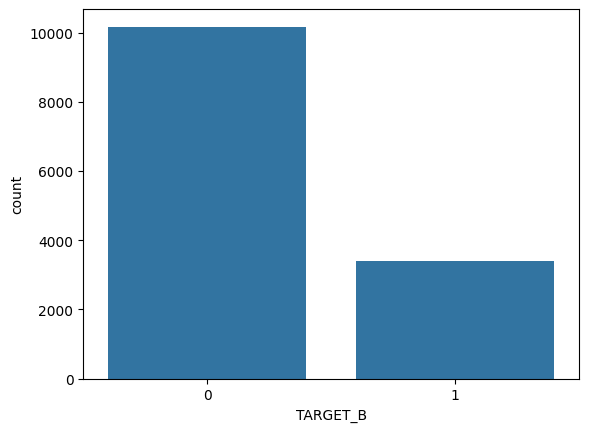

In [50]:
sns.countplot(data=data, x='TARGET_B')

# Missing Values

In [51]:
pd.merge(data.isna().sum().to_frame('N Missing'), data.isna().sum().to_frame('% Missing') / len(data) * 100, left_index=True, right_index=True)

,N Missing,% Missing
CARD_PROM_12,263,1.939528
CHILDREN,262,1.932153
DONOR_AGE,3554,26.209440
DONOR_GENDER,272,2.005900
FILE_CARD_GIFT,260,1.917404
FREQUENCY_STATUS_97NK,282,2.079646
HOME_OWNER,286,2.109145
INCOME_GROUP,3289,24.255162
LAST_GIFT_AMT,261,1.924779
LIFETIME_CARD_PROM,260,1.917404


In [20]:
data['WEALTH_RATING'].value_counts(normalize=True, dropna=False)

WEALTH_RATING
 NaN          0.462389
 9.000000     0.069617
 8.000000     0.061873
 7.000000     0.060251
 5.000000     0.055088
 6.000000     0.053982
 3.000000     0.053245
 4.000000     0.052876
 2.000000     0.047566
 1.000000     0.041150
 0.000000     0.032448
-3.752821     0.005236
 13.451898    0.004277
Name: proportion, dtype: float64

In [21]:
data['INCOME_GROUP'].value_counts(normalize=True, dropna=False)

INCOME_GROUP
 NaN         0.242552
 5.000000    0.160841
 2.000000    0.129425
 4.000000    0.126475
 1.000000    0.089823
 3.000000    0.082891
 6.000000    0.080236
 7.000000    0.077729
 9.503280    0.005015
-1.737977    0.005015
Name: proportion, dtype: float64

In [52]:
data.isna().sum(axis=1).value_counts()

1    4324
2    3592
0    2345
3    2136
4     840
5     265
6      52
7       5
8       1
Name: count, dtype: int64

In [ ]:
data[['']]

In [53]:
data[data.isna().sum(axis=1) >= 5]

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
63257,6.0,0.0,NaN,M,3.0,2.0,U,NaN,11.0,12.0,40.0,4.0,15.0,4.0,25.0,347.0,219.000000,NaN,17.0,7.547111,12.0,0.0,42.0,20.0,24.0,80.0,1.0,12850.0,A,NaN,12.000000,3.000000,0.375,3.0,0.231,0.0,3,C,NaN,0
50072,6.0,3.0,NaN,F,6.0,4.0,U,NaN,5.0,18.0,NaN,11.0,7.0,5.0,48.0,329.0,185.000000,NaN,17.0,17.000000,14.0,0.0,28.0,34.0,36.0,88.0,1.0,9344.0,A,5.50,5.500000,4.000000,NaN,4.0,0.211,0.0,3,R,NaN,0
112167,4.0,NaN,NaN,F,0.0,1.0,U,NaN,20.0,5.0,20.0,1.0,20.0,20.0,12.0,317.0,145.000000,18.0,18.0,18.000000,10.0,0.0,36.0,23.0,51.0,88.0,0.0,NaN,NaN,0.00,20.000000,0.000000,0.000,1.0,0.200,0.0,3,R,NaN,0
53212,NaN,3.0,NaN,F,2.0,1.0,U,NaN,16.0,NaN,26.0,2.0,16.0,10.0,23.0,814.0,-190.662683,29.0,23.0,23.000000,11.0,3.0,24.0,30.0,30.0,24.0,0.0,15419.0,A,13.00,13.000000,2.000000,0.333,2.0,0.154,0.0,2,R,NaN,0
130493,6.0,4.0,NaN,F,9.0,1.0,U,NaN,30.0,27.0,533.0,19.0,50.0,6.0,72.0,849.0,285.000000,80.0,20.0,NaN,NaN,0.0,34.0,38.0,19.0,49.0,1.0,14907.0,A,40.00,40.000000,2.000000,0.182,NaN,0.100,15.0,1,S,6.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48966,6.0,4.0,NaN,M,1.0,1.0,H,5.0,31.0,13.0,83.0,3.0,31.0,25.0,30.0,866.0,385.000000,32.0,17.0,17.000000,13.0,0.0,42.0,8.0,NaN,86.0,0.0,20684.0,A,25.00,27.670000,1.000000,0.111,3.0,0.158,0.0,NaN,NaN,NaN,0
2311,11.0,0.0,NaN,M,6.0,4.0,U,NaN,7.0,27.0,80.0,15.0,10.0,NaN,66.0,817.0,488.000000,62.0,7.0,15.000000,26.0,0.0,0.0,0.0,0.0,95.0,0.0,18712.0,A,6.67,6.000000,3.000000,NaN,7.0,0.333,0.0,?,?,NaN,1
28759,5.0,3.0,NaN,M,10.0,1.0,U,NaN,10.0,32.0,132.0,21.0,10.0,3.0,74.0,0.0,0.000000,126.0,25.0,28.000000,11.0,0.0,NaN,44.0,20.0,0.0,1.0,0.0,A,NaN,5.500000,-3.695219,0.300,4.0,0.235,3.0,1,R,NaN,0


In [54]:
for var in data.columns[1:-1]:
    var_value_counts = data[data[var].isna()]['TARGET_B'].value_counts(normalize=True)
    print(var)
    display(var_value_counts)

CHILDREN


TARGET_B
0    0.740458
1    0.259542
Name: proportion, dtype: float64

DONOR_AGE


TARGET_B
0    0.755205
1    0.244795
Name: proportion, dtype: float64

DONOR_GENDER


...

TARGET_B
0    0.802198
1    0.197802
Name: proportion, dtype: float64

URBANICITY


TARGET_B
0    0.784387
1    0.215613
Name: proportion, dtype: float64

WEALTH_RATING


TARGET_B
0    0.763477
1    0.236523
Name: proportion, dtype: float64

# Outliers

In [55]:
num_cols = data.select_dtypes(include=np.number).columns.drop(['INCOME_GROUP',
    'RECENT_STAR_STATUS', 'WEALTH_RATING', 'TARGET_B'])

In [56]:
outlier_count_IQR(data, num_cols)

,N Outliers
CARD_PROM_12,1261
CHILDREN,133
DONOR_AGE,6
FILE_CARD_GIFT,437
FREQUENCY_STATUS_97NK,0
LAST_GIFT_AMT,553
LIFETIME_CARD_PROM,6
LIFETIME_GIFT_AMOUNT,803
LIFETIME_GIFT_COUNT,588
LIFETIME_MAX_GIFT_AMT,874


In [57]:
outlier_count_IQR(data, num_cols, outlier_type='extreme')

,N Outliers
CARD_PROM_12,265
CHILDREN,0
DONOR_AGE,0
FILE_CARD_GIFT,12
FREQUENCY_STATUS_97NK,0
LAST_GIFT_AMT,234
LIFETIME_CARD_PROM,0
LIFETIME_GIFT_AMOUNT,377
LIFETIME_GIFT_COUNT,89
LIFETIME_MAX_GIFT_AMT,561


In [58]:
outlier_filter_IQR(data, num_cols)

Excluding all normal outliers, we are left with 12.57% of our dataset


In [59]:
outlier_filter_IQR(data, num_cols, outlier_type='extreme')

Excluding all extreme outliers, we are left with 23.21% of our dataset


In [60]:
data[num_cols].quantile(0.95)

CARD_PROM_12                       6.000
CHILDREN                           4.000
DONOR_AGE                         83.000
FILE_CARD_GIFT                    15.000
FREQUENCY_STATUS_97NK              4.000
LAST_GIFT_AMT                     30.000
LIFETIME_CARD_PROM                32.000
LIFETIME_GIFT_AMOUNT             284.700
LIFETIME_GIFT_COUNT               28.000
LIFETIME_MAX_GIFT_AMT             36.000
LIFETIME_MIN_GIFT_AMT             23.000
LIFETIME_PROM                     84.000
MEDIAN_HOME_VALUE               3290.050
MEDIAN_HOUSEHOLD_INCOME          642.000
MONTHS_SINCE_FIRST_GIFT          128.000
MONTHS_SINCE_LAST_GIFT            26.000
MONTHS_SINCE_LAST_PROM_RESP       26.000
NUMBER_PROM_12                    24.000
PCT_ATTRIBUTE1                     5.000
PCT_ATTRIBUTE2                    49.000
PCT_ATTRIBUTE3                    55.650
PCT_ATTRIBUTE4                    65.000
PCT_OWNER_OCCUPIED                95.000
PEP_STAR                           1.000
PER_CAPITA_INCOM

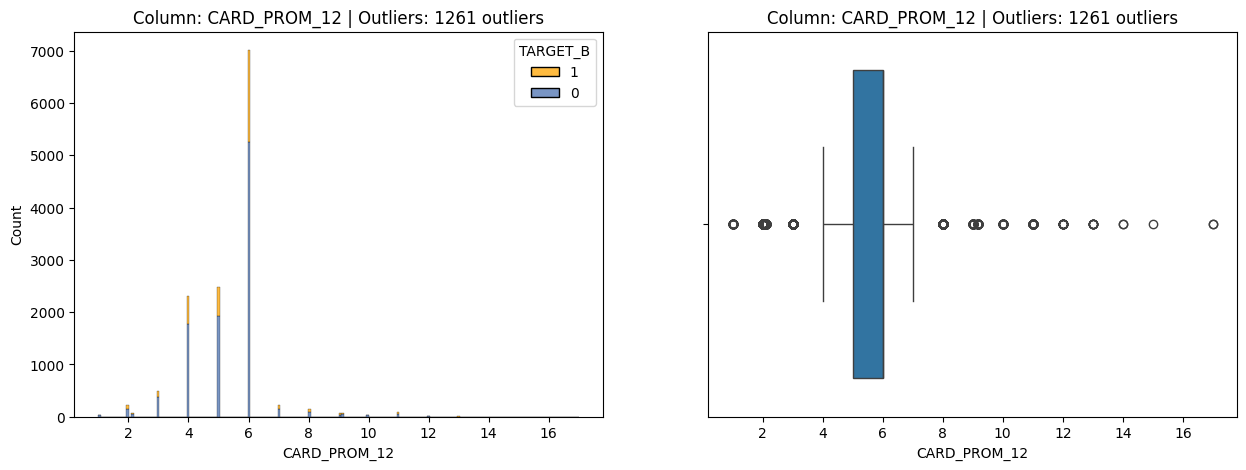

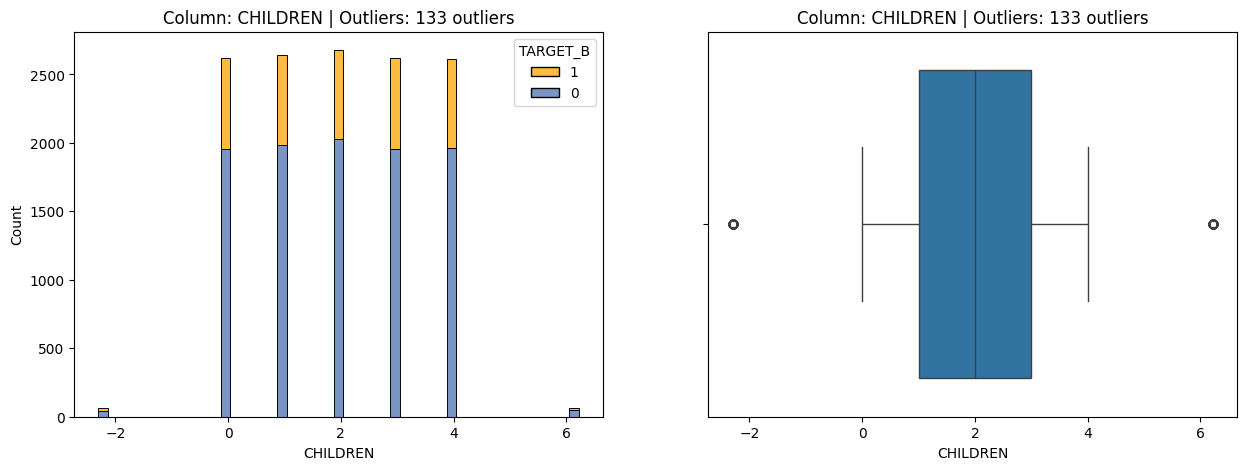

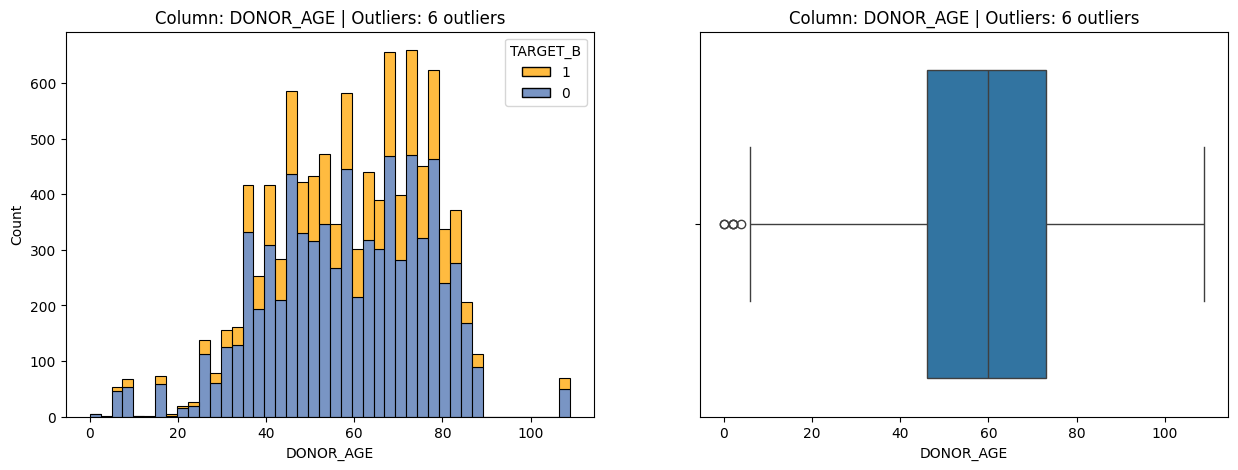

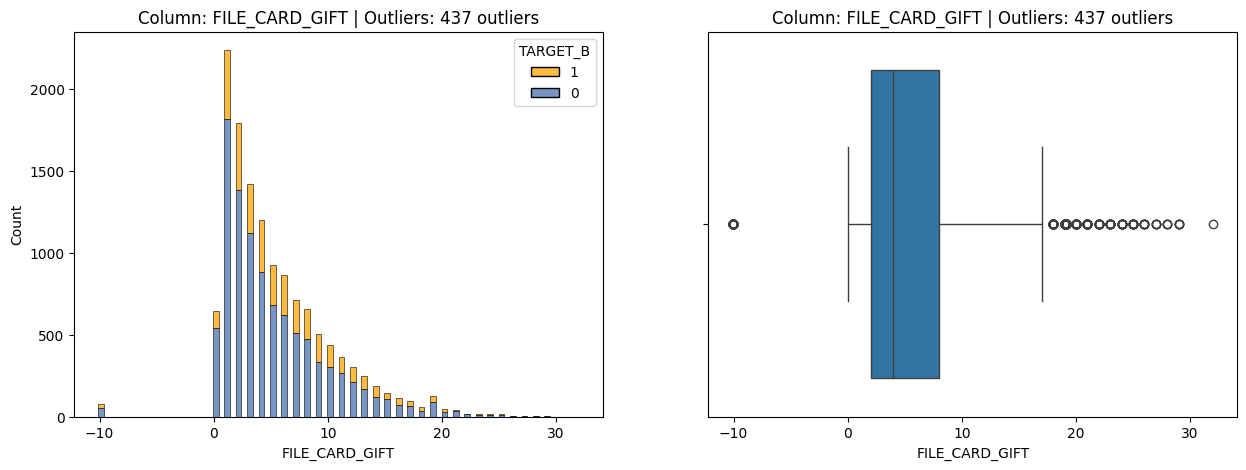

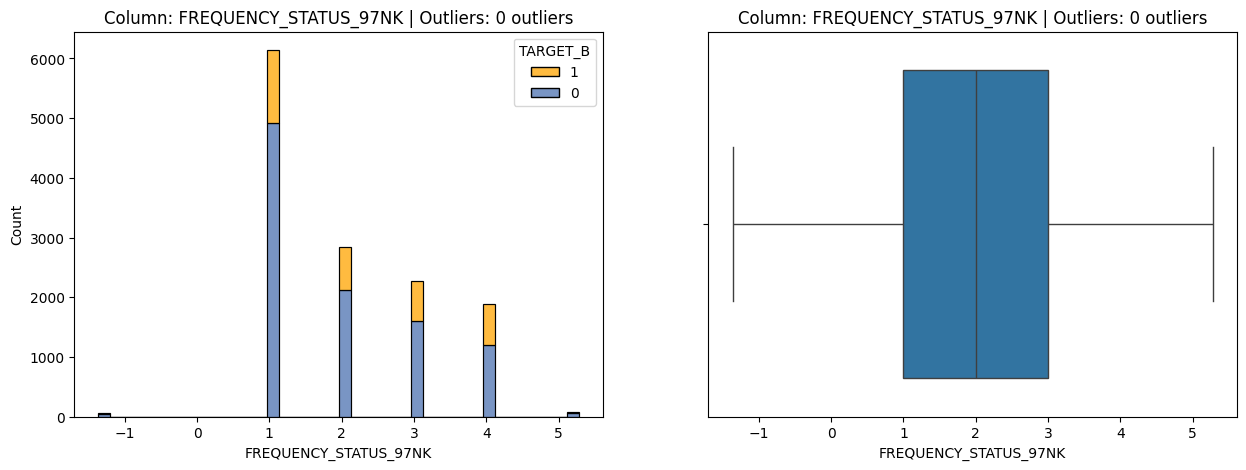

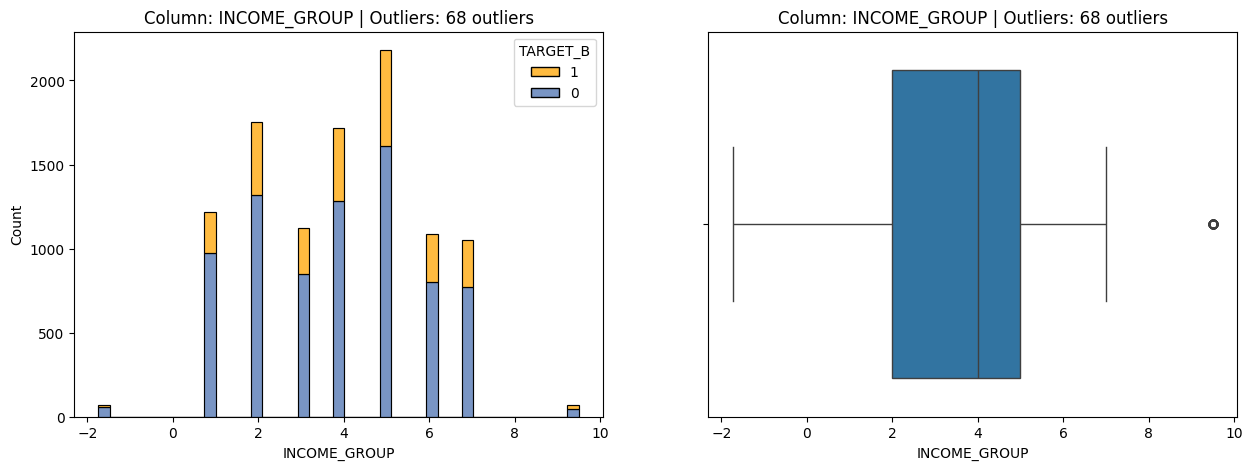

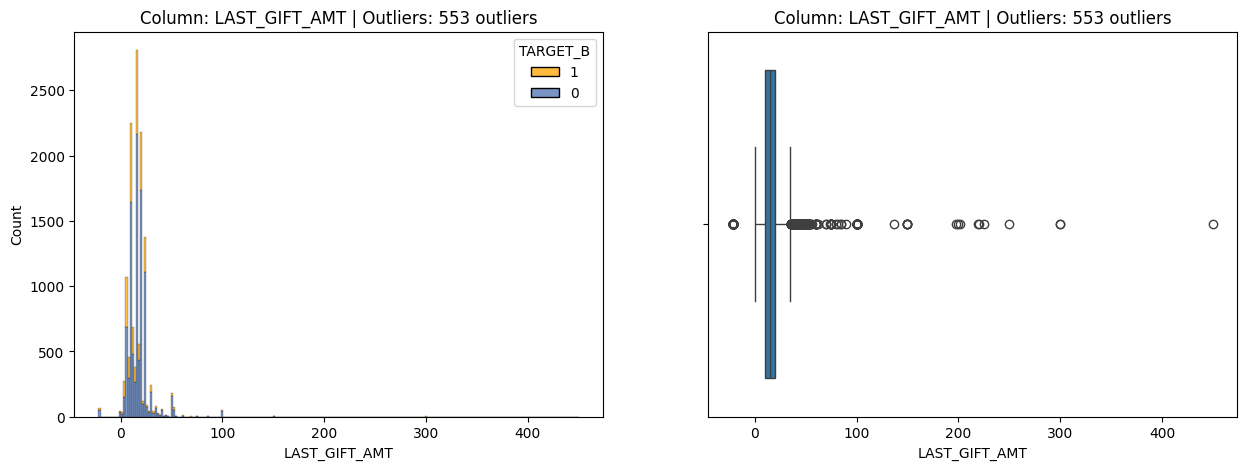

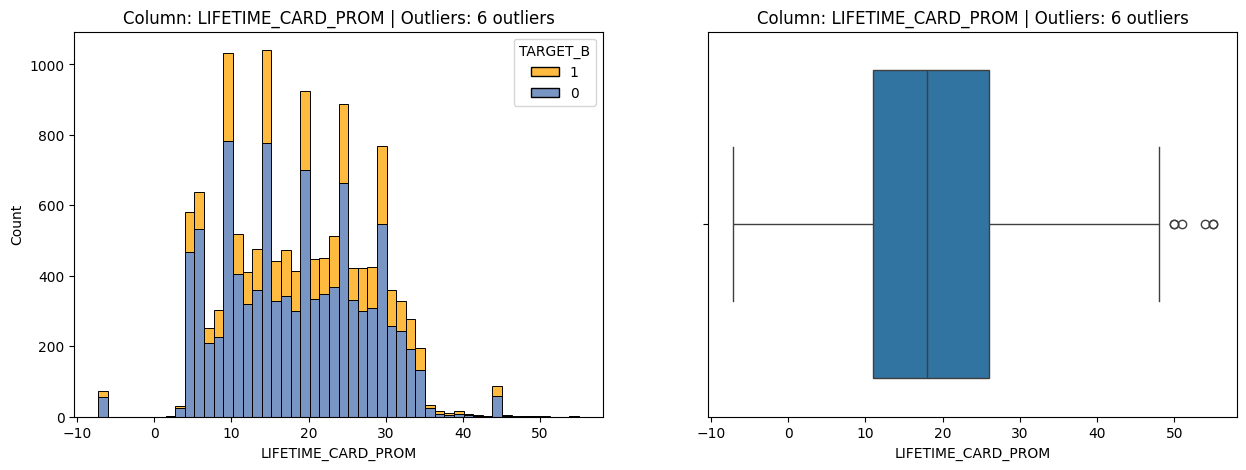

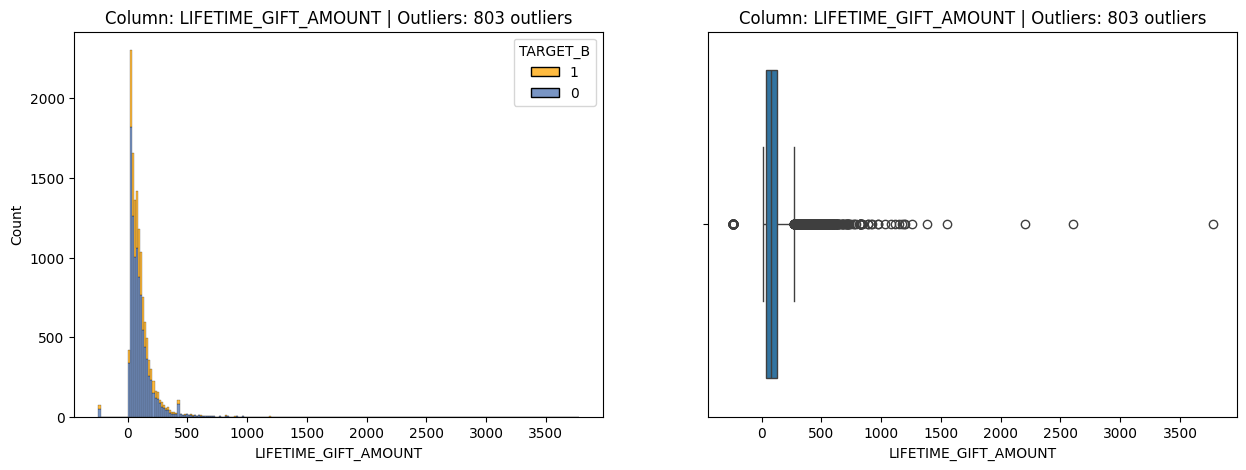

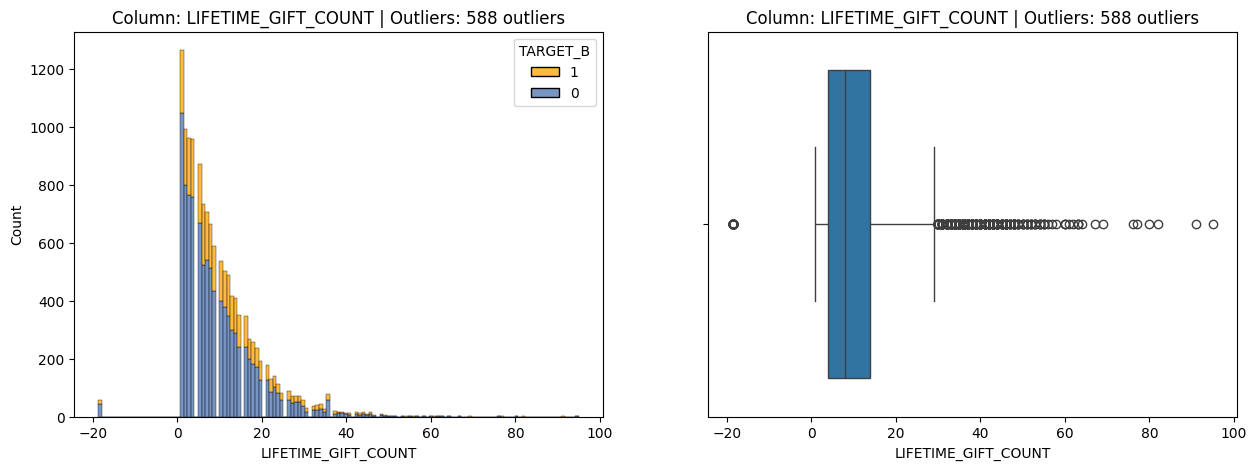

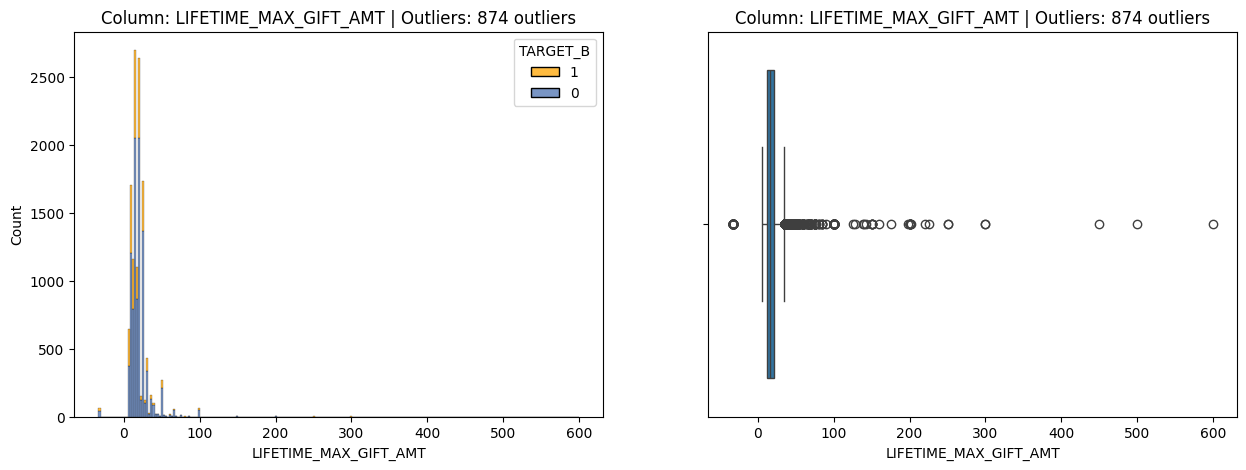

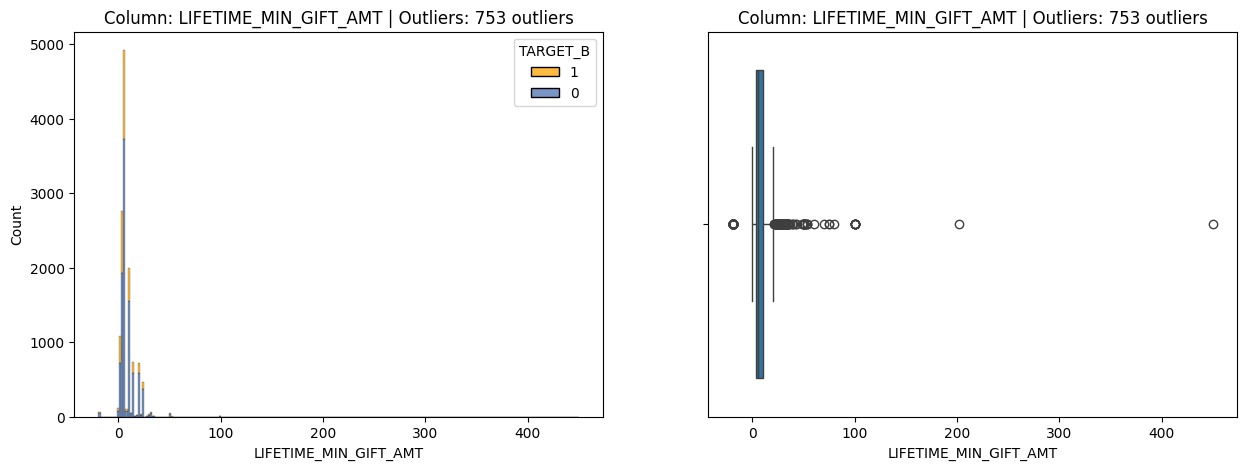

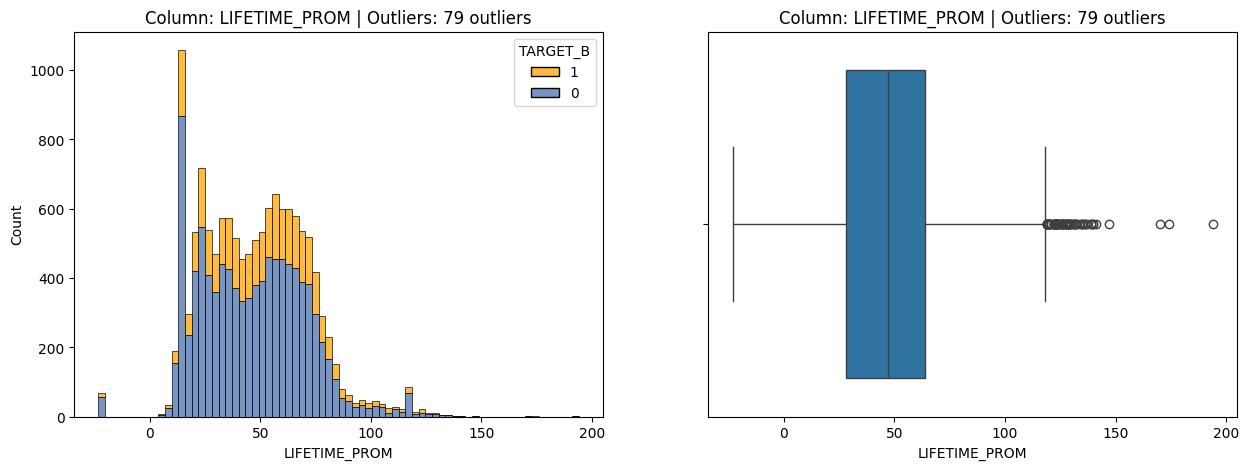

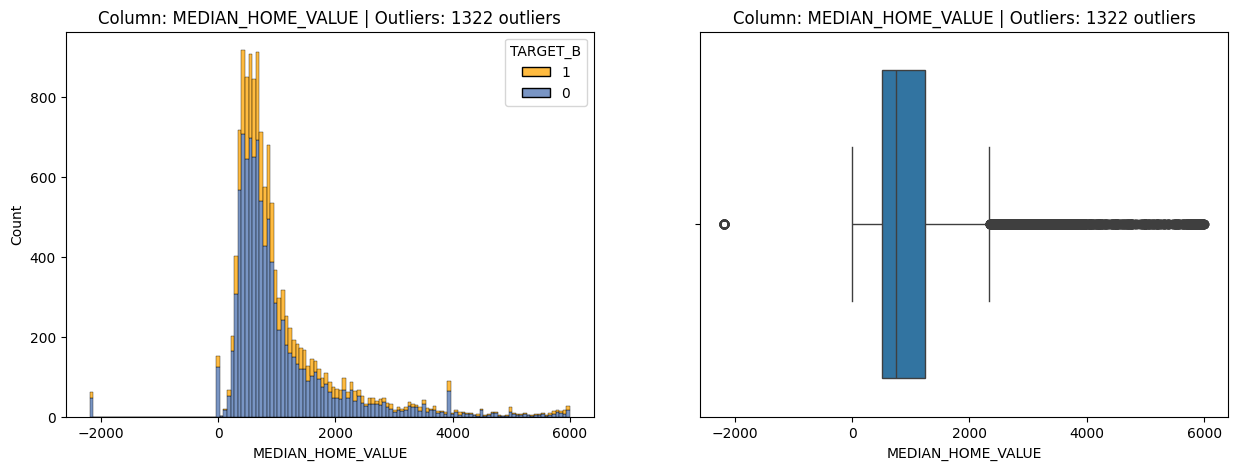

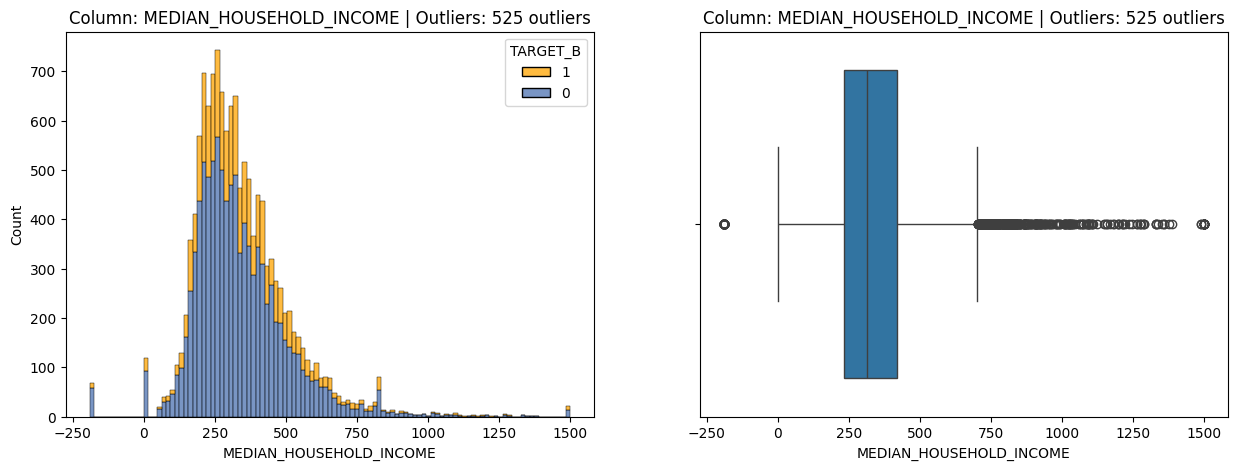

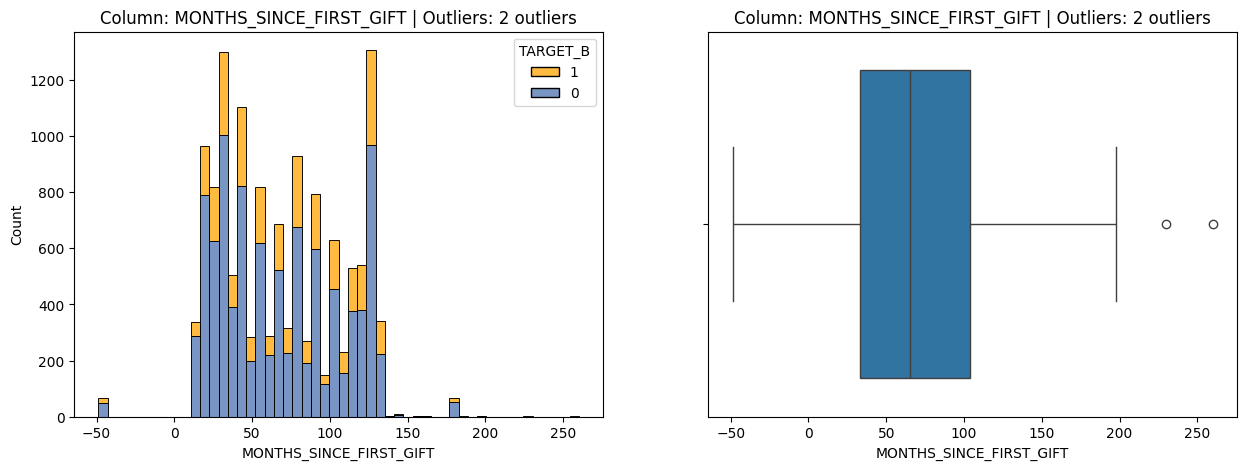

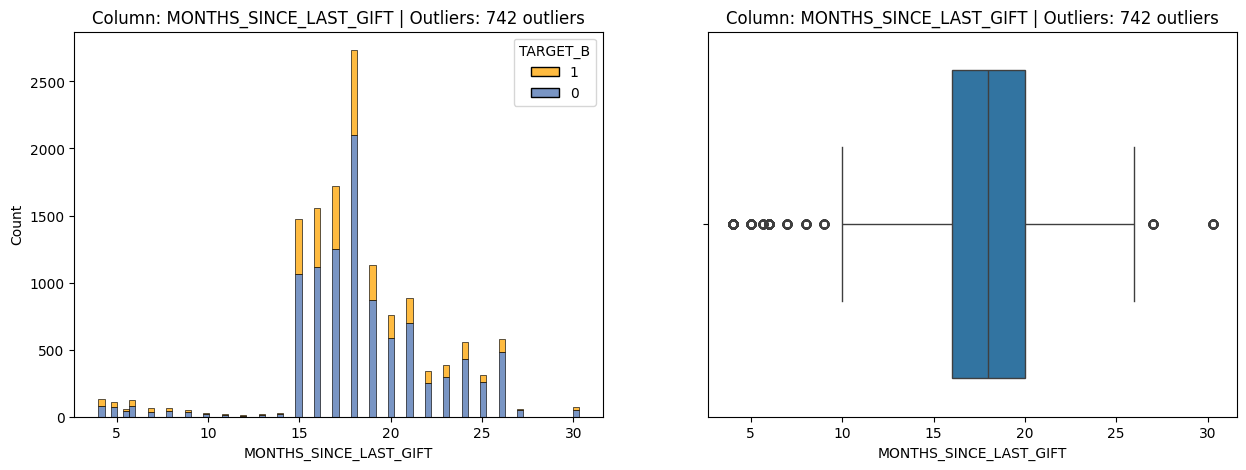

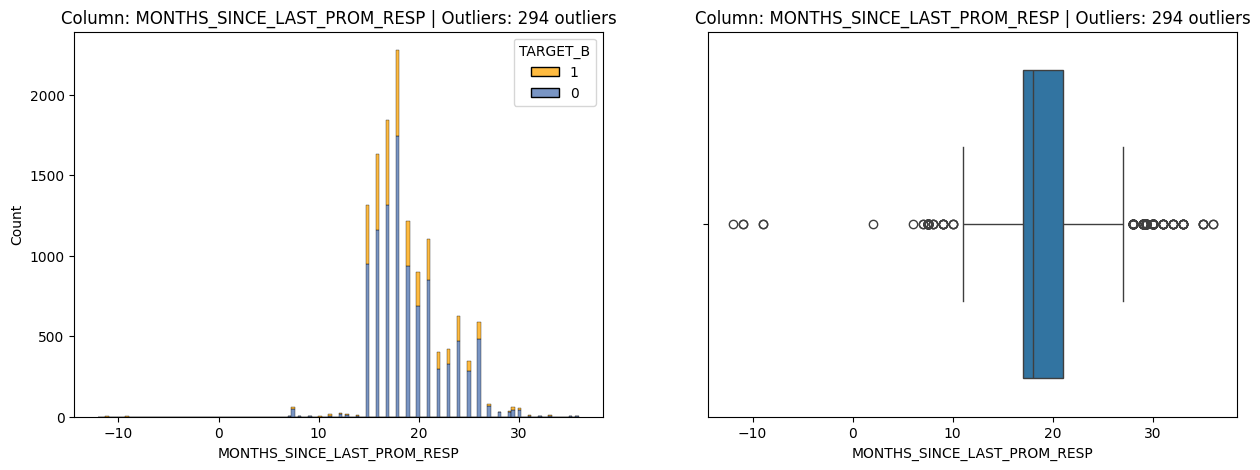

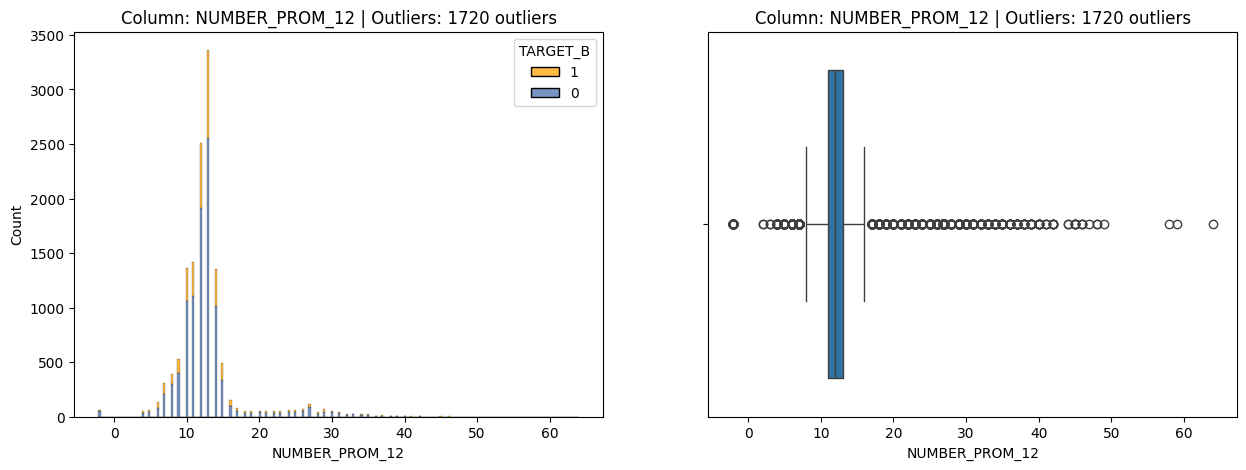

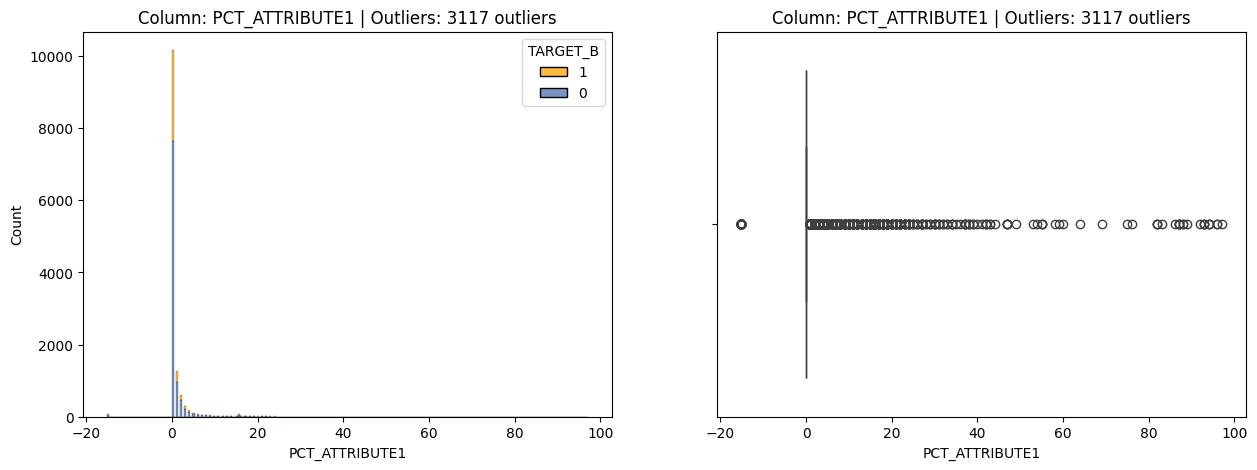

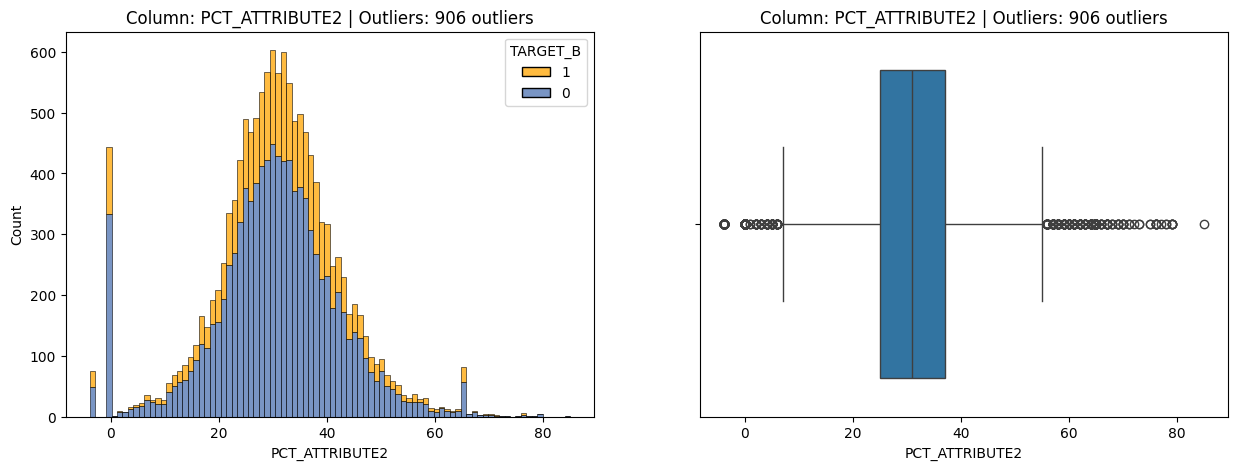

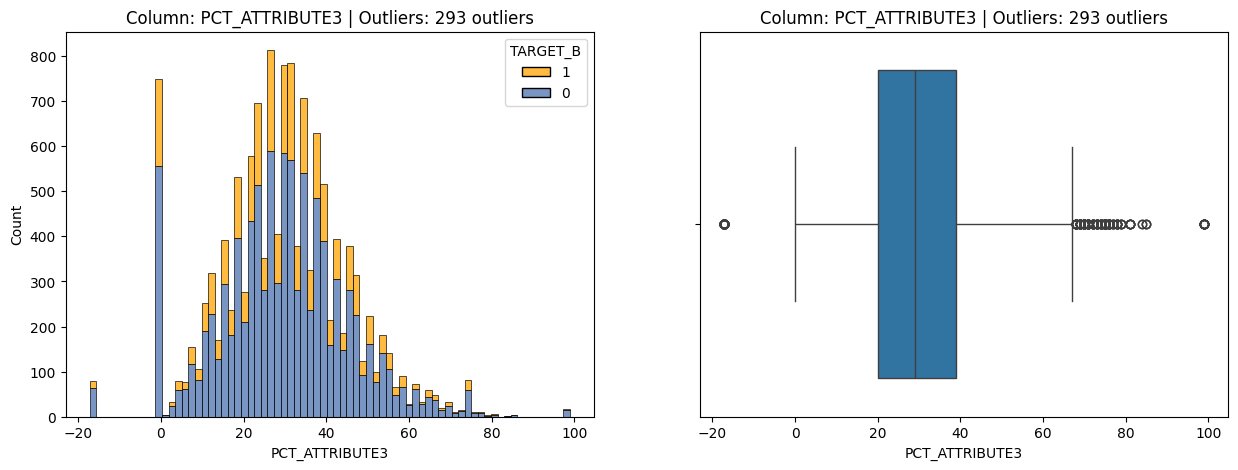

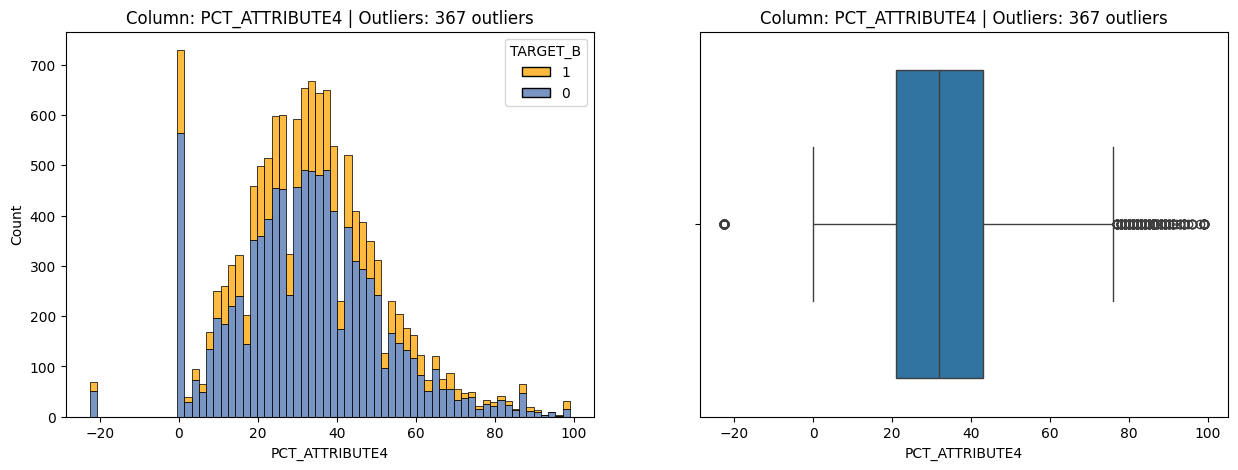

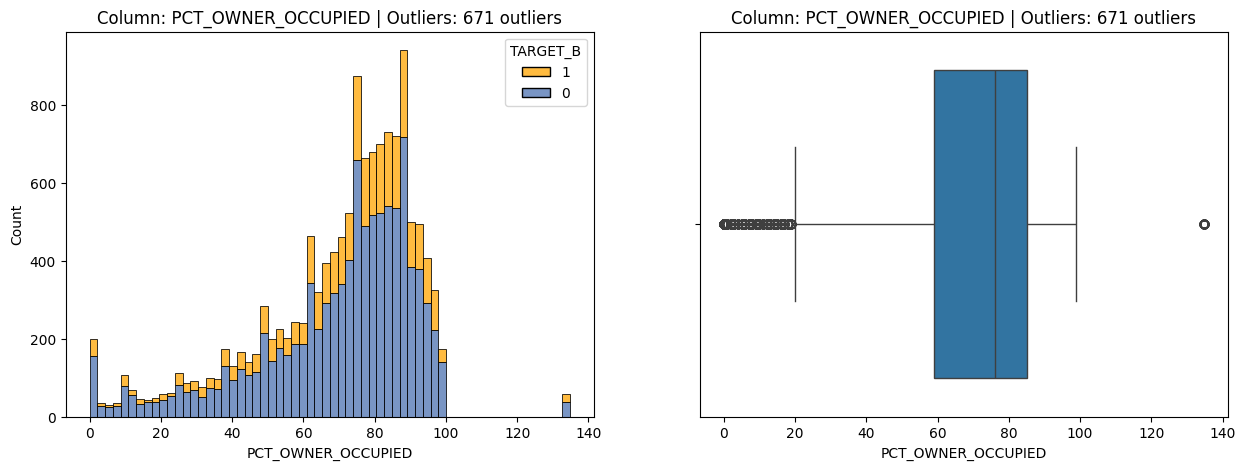

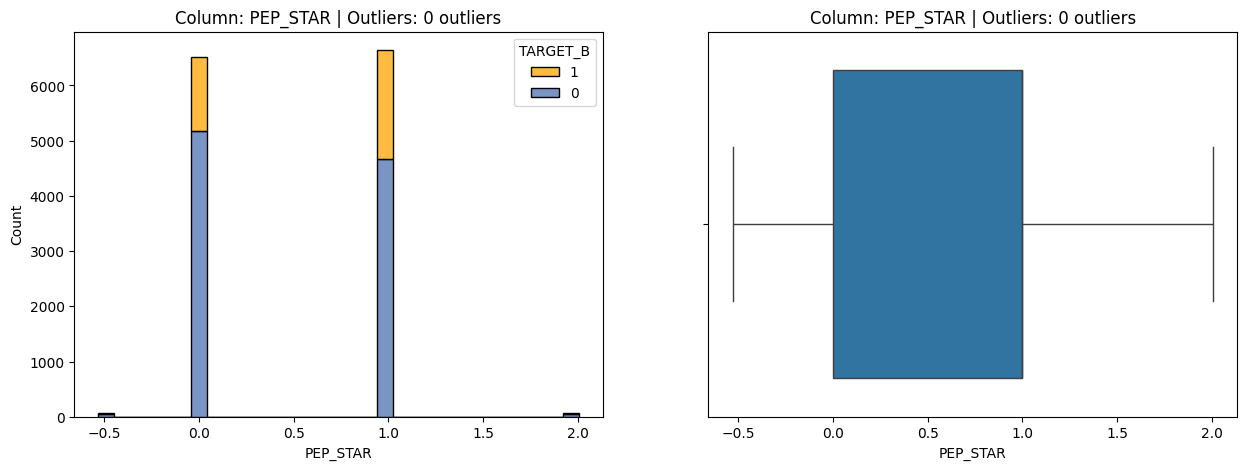

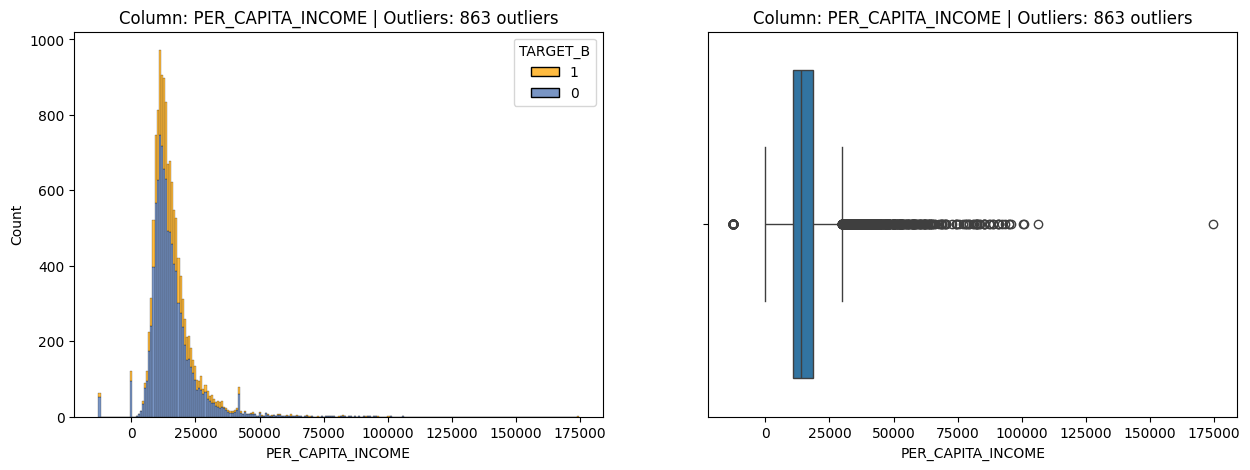

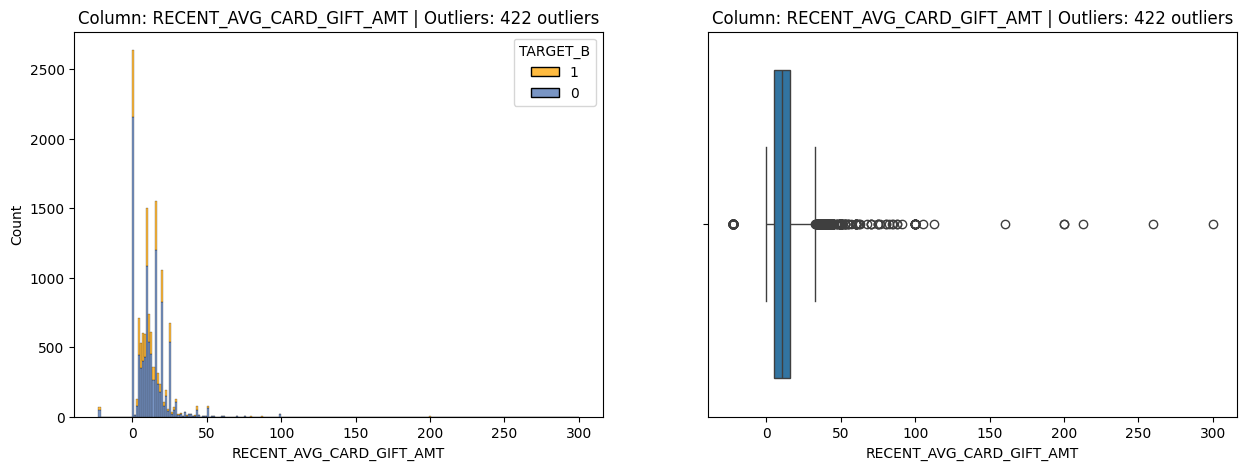

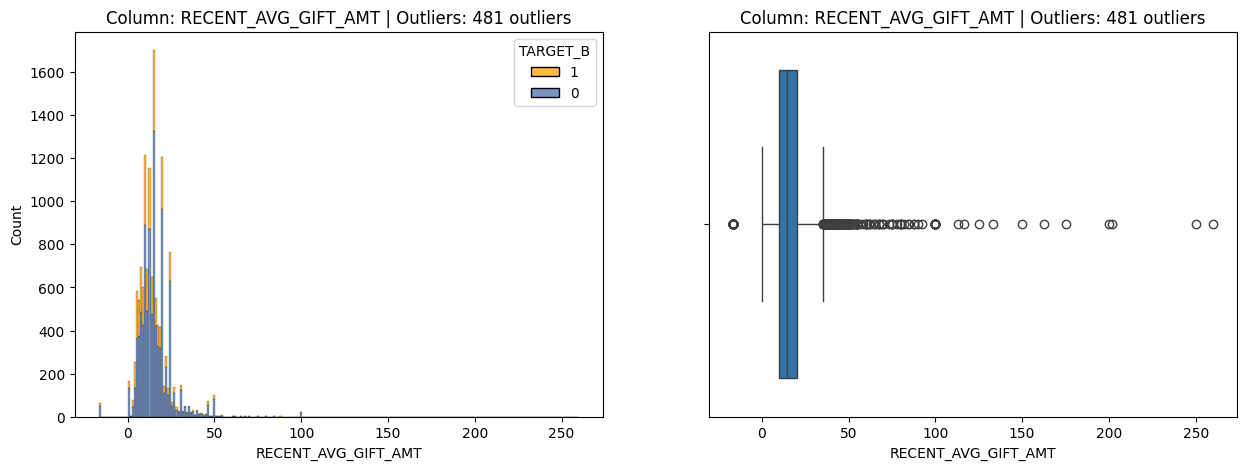

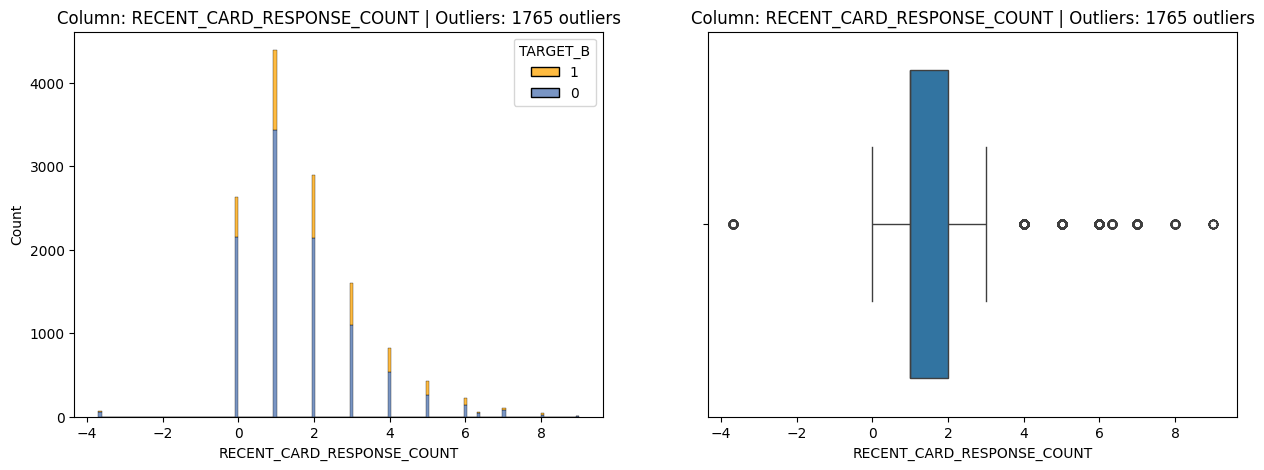

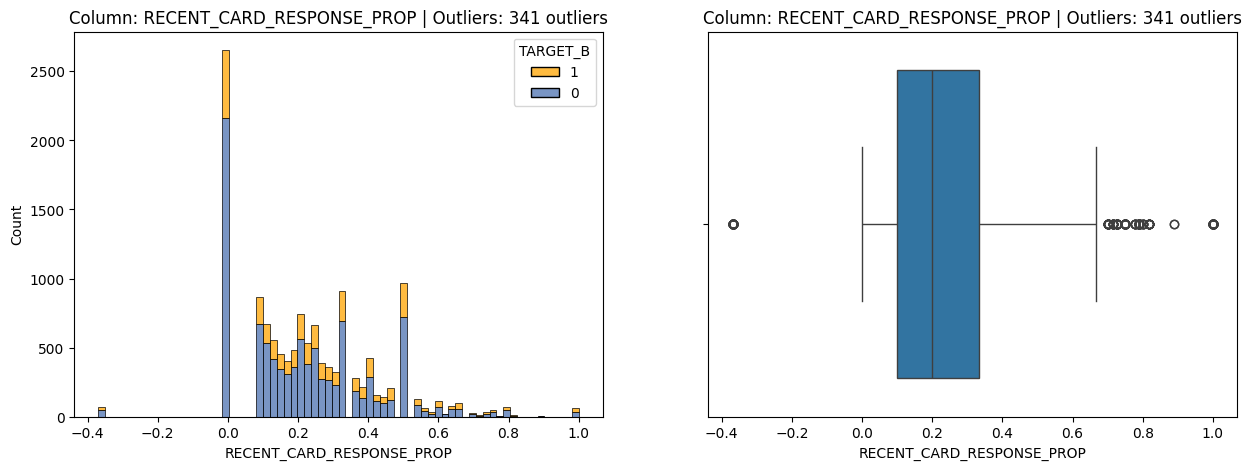

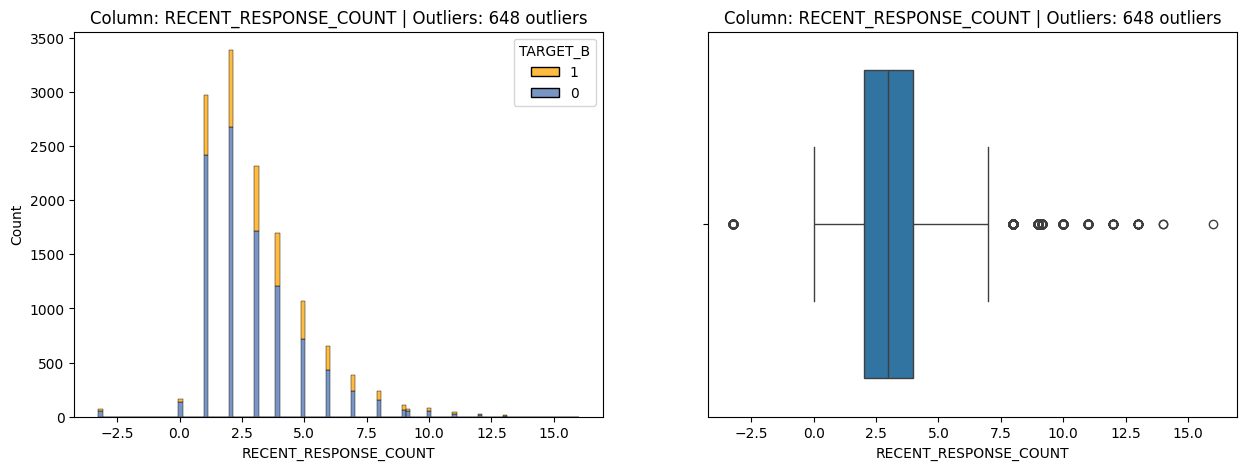

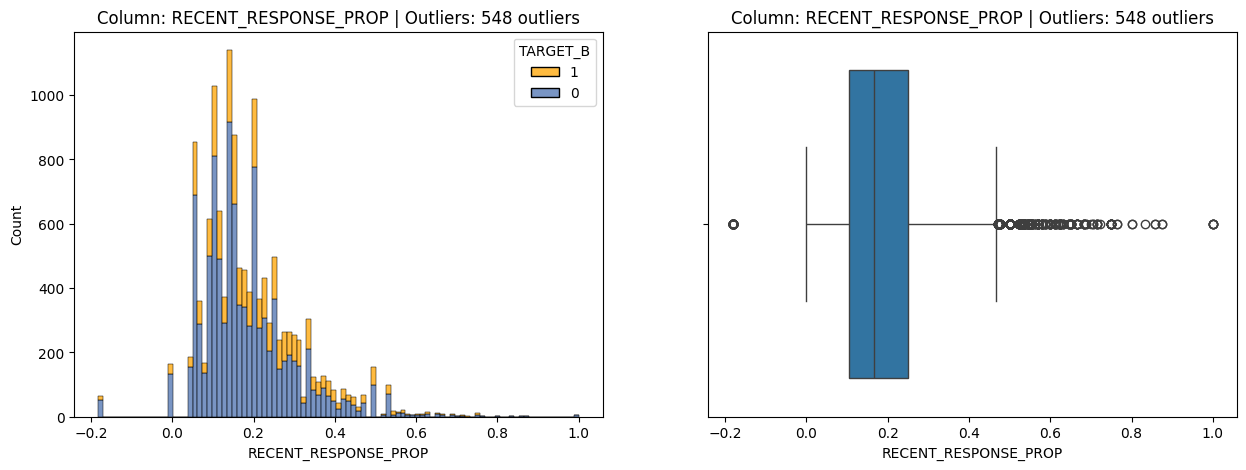

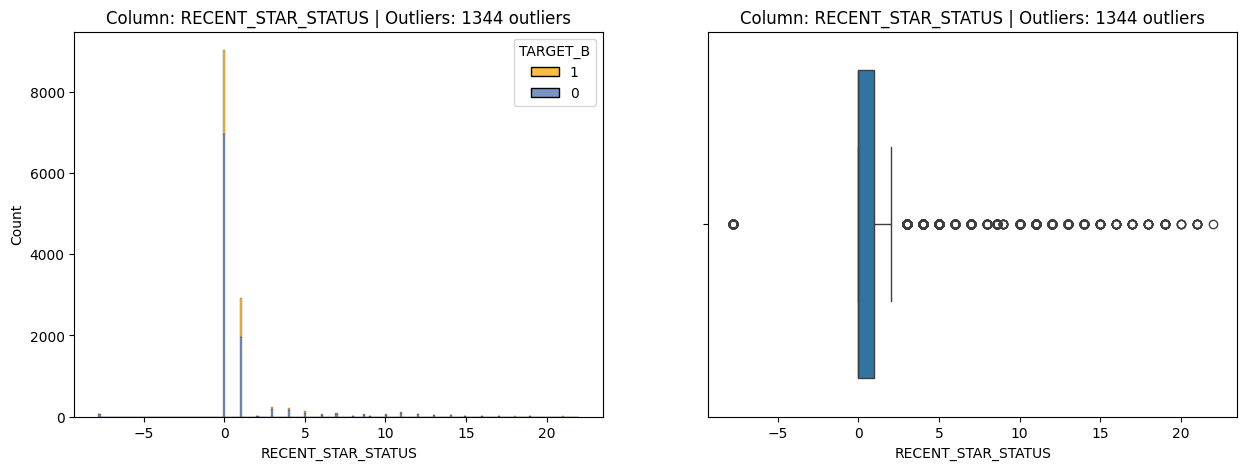

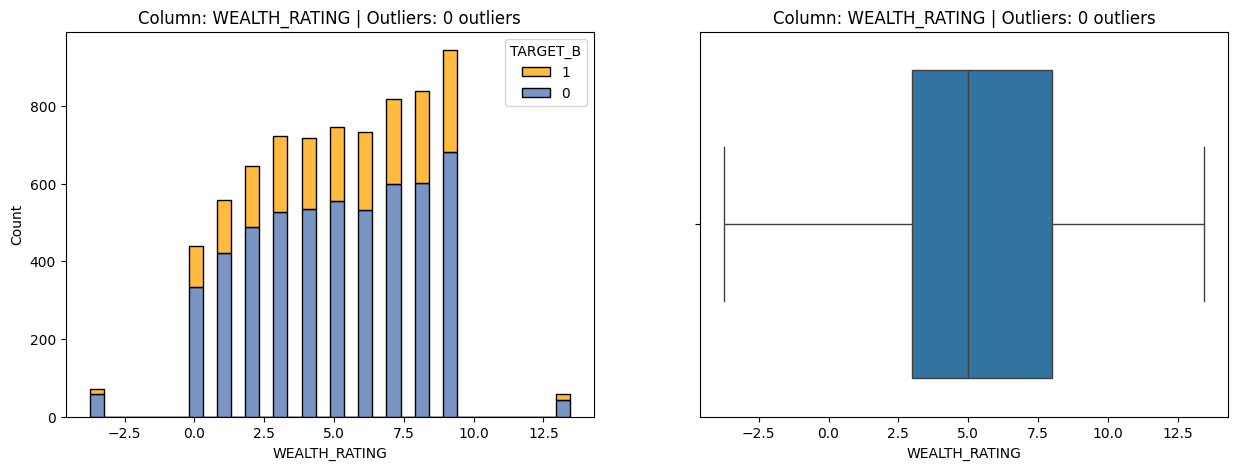

In [140]:
distribution_plot_grid(data, num_cols, target='TARGET_B', target_hue_order=[1,0], target_palette={0: '#4C72B0', 1: "orange"})

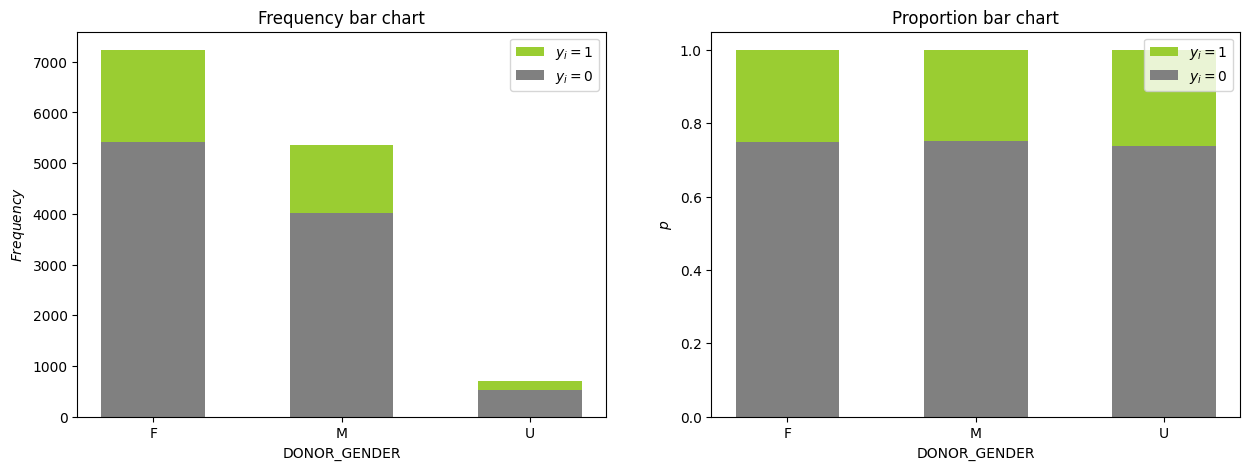

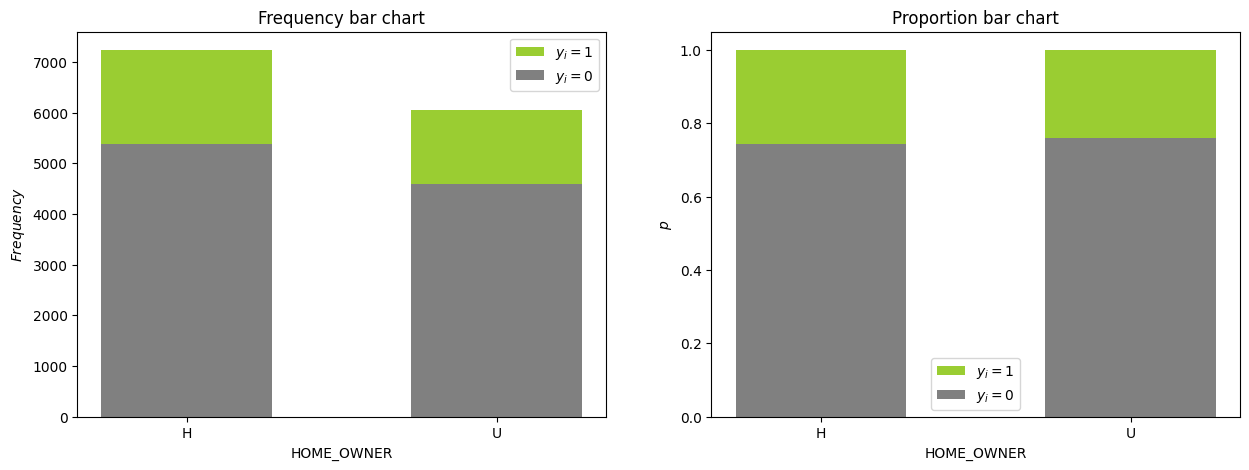

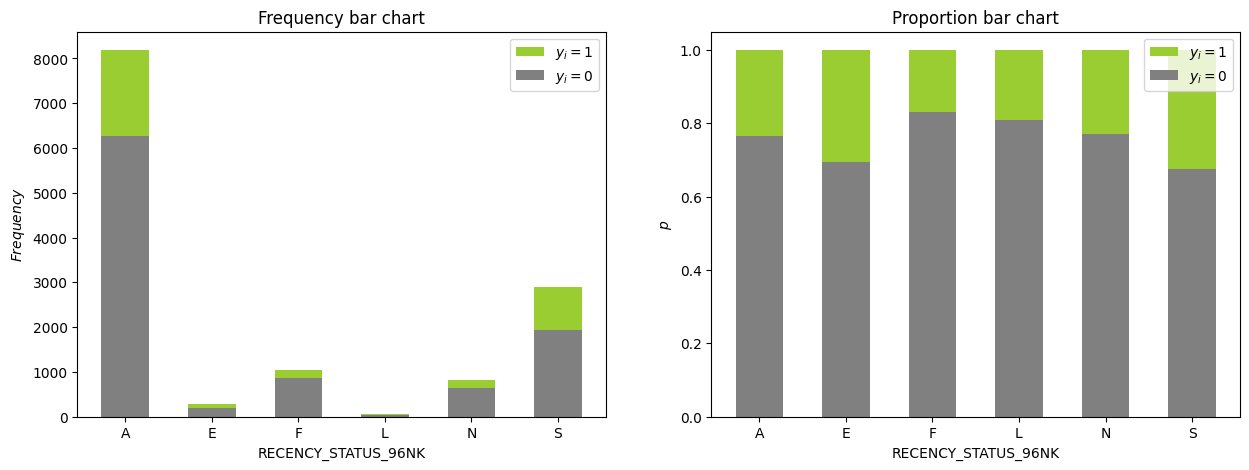

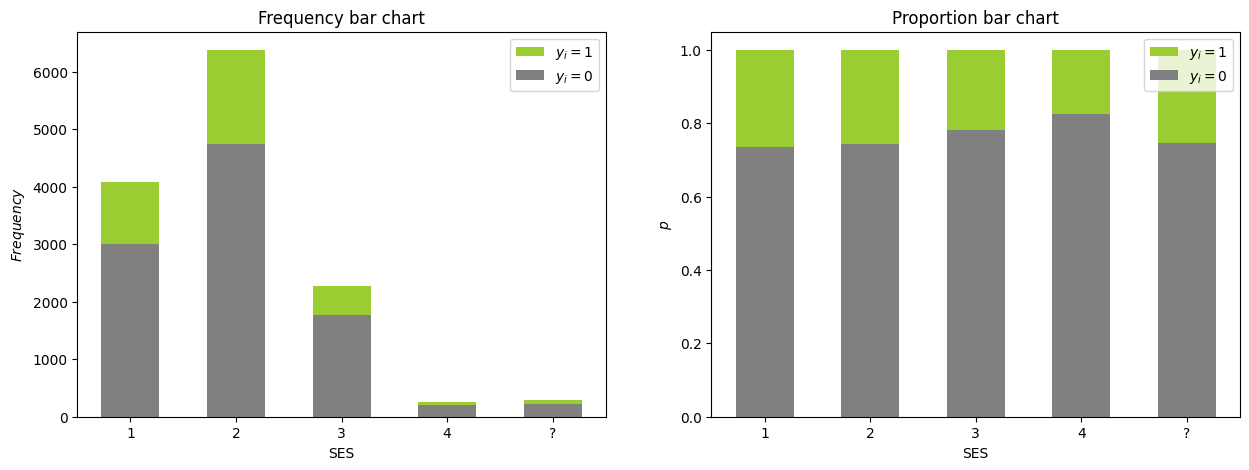

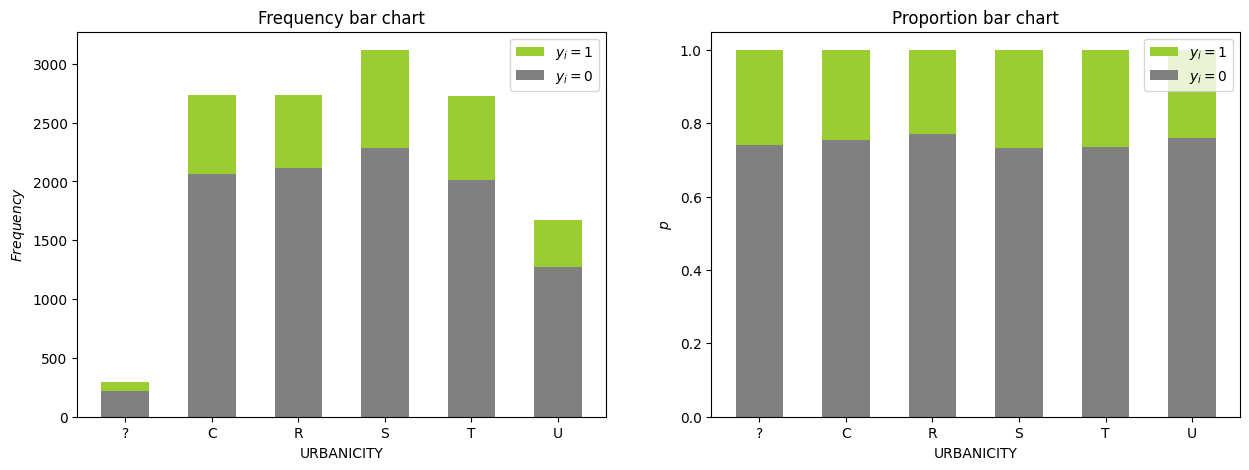

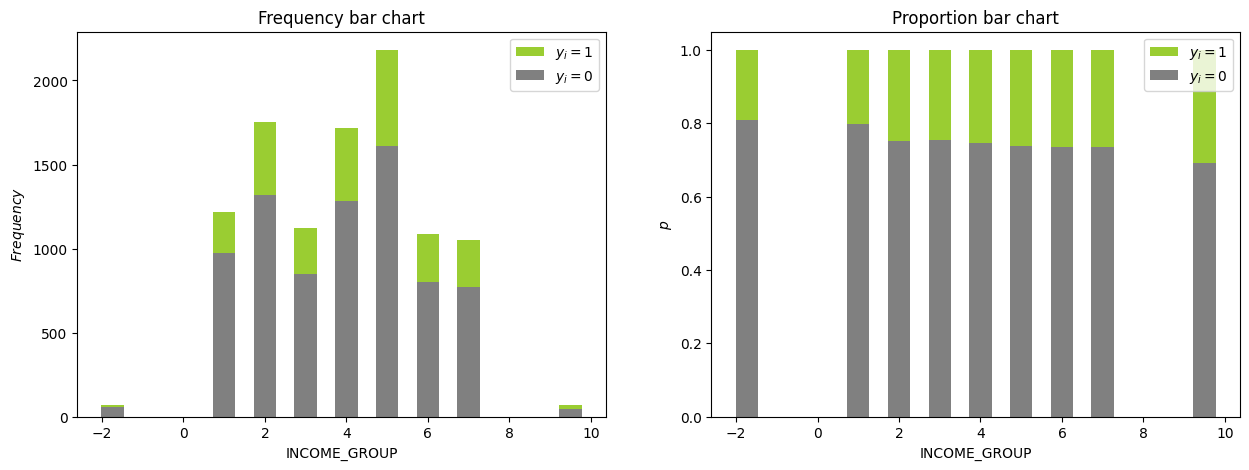

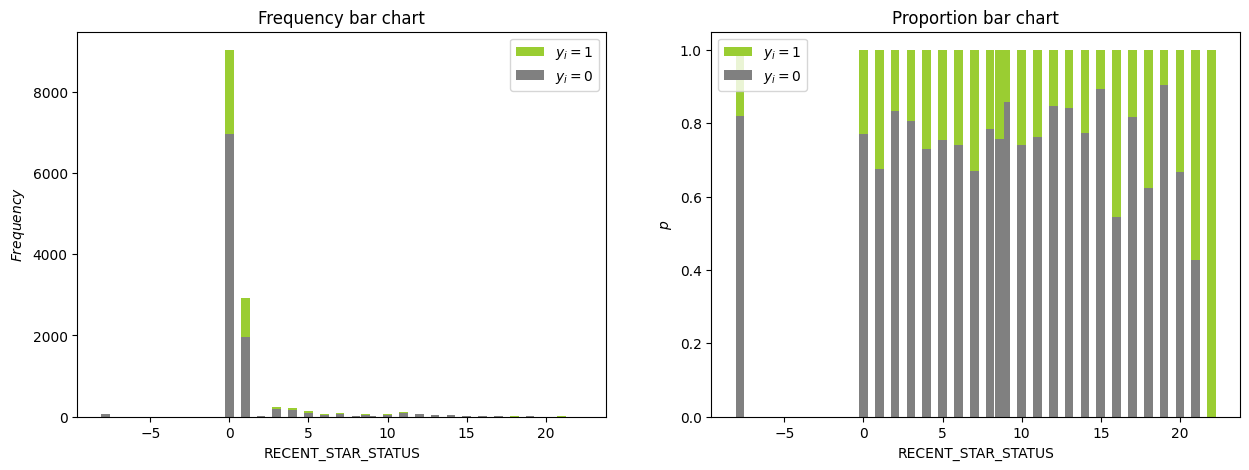

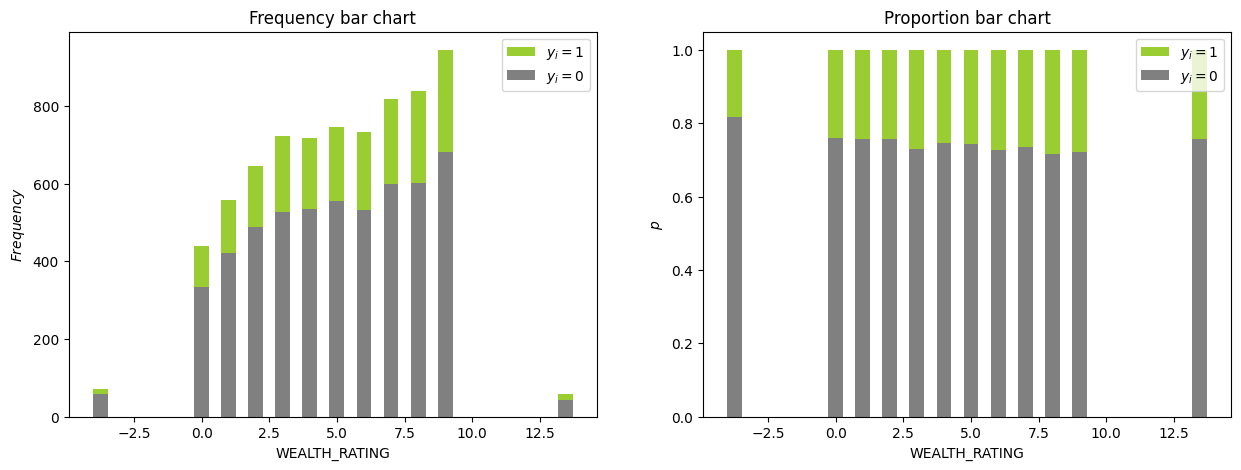

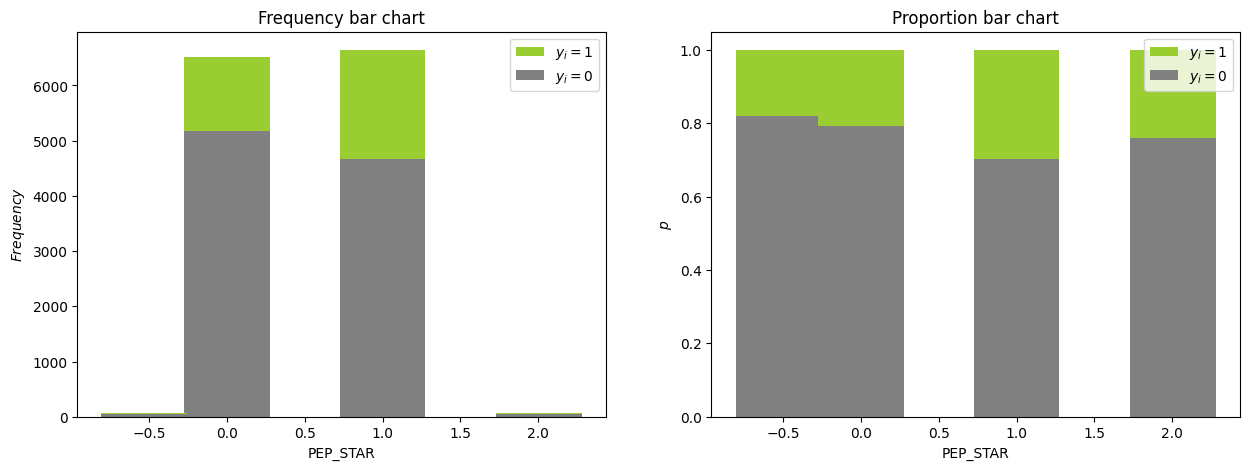

In [49]:
bar_charts_categorical(data, cat_cols, 'TARGET_B')

# Other/Extra

## Feature Selection?

In [252]:
from scipy.stats import chi2_contingency
def chi2_TestIndependence(data, target, variables, alpha=0.05):
    '''
    This function will follow the steps of chi-square to check if an
    independent variable is an important predictor towards a dependent
    variable. It receives the full dataset, the name of the dependent
    variable and a list of predictors to test as well as the signifcance level
    to be used for the test. It returns a dataframe containing a Keep or
    Discard verdict for each feature

    Parameters:
        ----------
         - data (pd.DataFrame): The DataFrame containing the data.
         - target (str): The name of the dependent variable
         - variables (list): The column names of the variables to be evaluated.
         - alpha (float): The significance level to consider for the chi-square
         test

    Returns:
        ----------
        A dataframe containing the results of the test
    '''
    chi2_check = []
    # Get the X and y datasets for the test
    X_chi = data.drop(target, axis=1)
    y = data[target]
    res = pd.DataFrame(columns=['chi2'])
    for var in variables:
        # If p-value < alpha, reject H0 (similarity across groups)
        # and keep feature
        if chi2_contingency(pd.crosstab(y, X_chi[var]))[1] < alpha:
            res.loc[var, 'chi2'] = 1
        else:
            res.loc[var, 'chi2'] = 0

    return res

In [253]:
chi2_res = chi2_TestIndependence(data, 'TARGET_B', cat_cols)
chi2_res

,chi2
DONOR_GENDER,0
HOME_OWNER,1
RECENCY_STATUS_96NK,1
SES,1
URBANICITY,1
INCOME_GROUP,1
RECENT_STAR_STATUS,1
WEALTH_RATING,0
PEP_STAR,1


In [248]:
chi2_res[chi2_res['chi2 Keep?'] == 0]['Column'].values

array(['DONOR_GENDER', 'WEALTH_RATING'], dtype=object)

In [54]:
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=100, encoded_missing_value=100)
encoded = encoder.fit_transform(data[cat_cols])
encoded

array([[  1.,   0.,   0., ...,   1., 100.,   1.],
       [  0.,   1.,   4., ...,   1., 100.,   1.],
       [  0.,   0.,   5., ...,   2., 100.,   2.],
       ...,
       [  1.,   1.,   0., ...,   1., 100.,   1.],
       [  1.,   1.,   4., ...,   1., 100.,   1.],
       [  0.,   0.,   5., ...,   2., 100.,   2.]], shape=(13560, 9))

In [55]:
anova = SelectKBest(f_classif, k='all')
X_anova = anova.fit_transform(encoded, data['TARGET_B'])
selected_features = pd.Series(anova.get_support(), index = cat_cols)
selected_features

DONOR_GENDER           True
HOME_OWNER             True
RECENCY_STATUS_96NK    True
SES                    True
URBANICITY             True
INCOME_GROUP           True
RECENT_STAR_STATUS     True
WEALTH_RATING          True
PEP_STAR               True
dtype: bool

In [56]:
feature_scores = pd.Series(anova.pvalues_, index = cat_cols)
feature_scores

DONOR_GENDER          0.88
HOME_OWNER            0.41
RECENCY_STATUS_96NK   0.66
SES                   0.02
URBANICITY            0.23
INCOME_GROUP          0.78
RECENT_STAR_STATUS    0.24
WEALTH_RATING         0.00
PEP_STAR              0.26
dtype: float64

In [19]:
corr = data[list(num_cols) + ['TARGET_B']].corr('spearman')

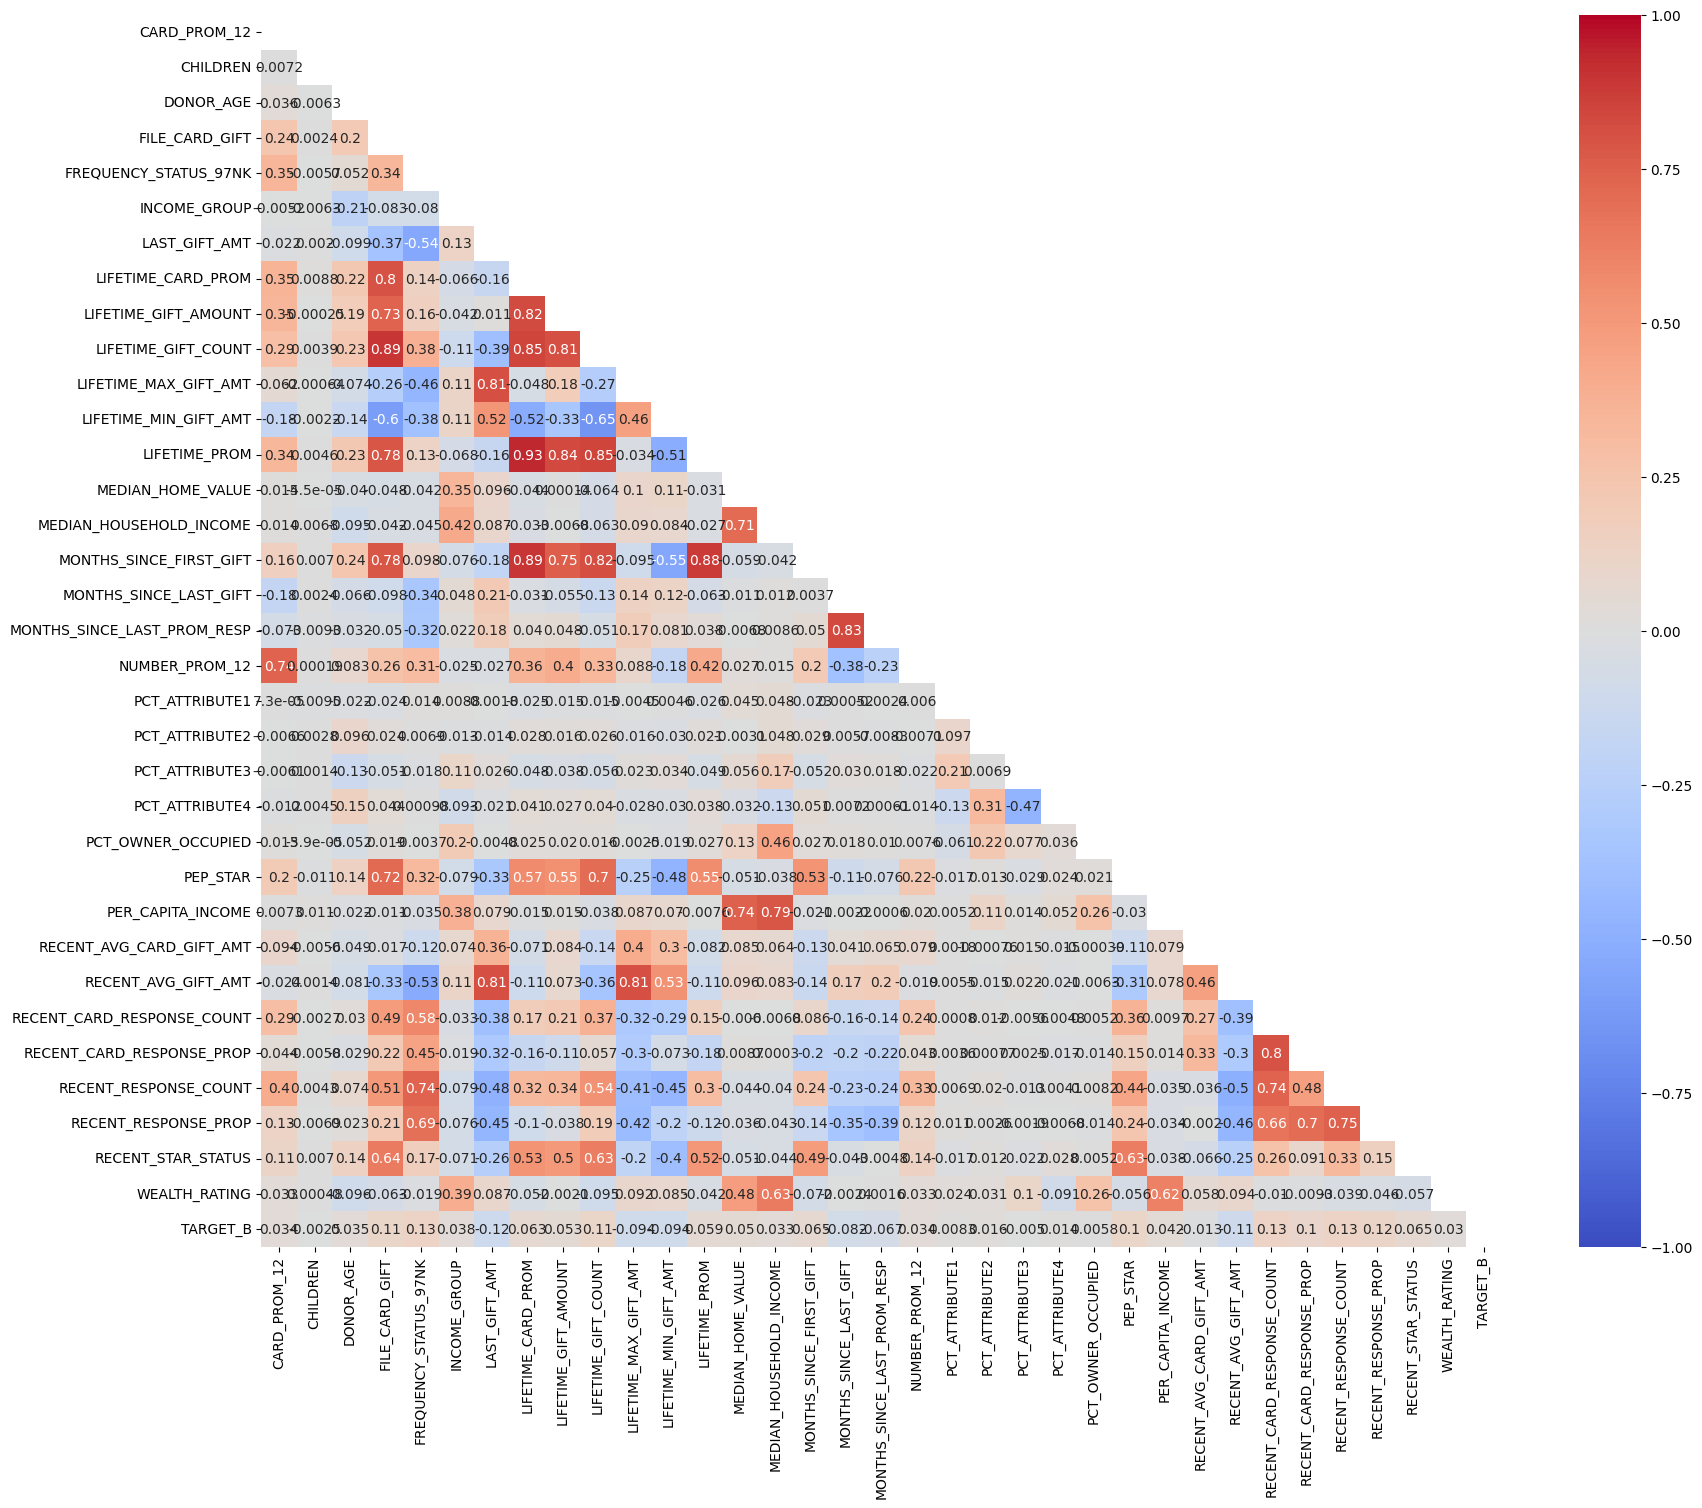

In [20]:
cor_heatmap(corr)